In [2]:
from pymatgen.core import Structure
from pymatgen.core.periodic_table import Element
import numpy as np

spinel_structure = Structure.from_file("/home/gaotianjiao/modnet-master/ext_struc/perovskite_cif/mp-605034.cif")
print(f"晶胞中总原子数: {len(spinel_structure)}")
print(f"化学式: {spinel_structure.formula}")
print(f"晶格参数: a={spinel_structure.lattice.a:.4f}, "
      f"b={spinel_structure.lattice.b:.4f}, "
      f"c={spinel_structure.lattice.c:.4f}")
print(f"晶格角度: alpha={spinel_structure.lattice.alpha:.2f}, "
      f"beta={spinel_structure.lattice.beta:.2f}, "
      f"gamma={spinel_structure.lattice.gamma:.2f}")

晶胞中总原子数: 36
化学式: K8 Ni4 F24
晶格参数: a=8.0026, b=8.0026, c=8.0026
晶格角度: alpha=90.00, beta=90.00, gamma=90.00


/# 对称性分析

初步查看

In [3]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
analyzer = SpacegroupAnalyzer(spinel_structure, symprec=0.01)
space_group = analyzer.get_space_group_number()
space_group_symbol = analyzer.get_space_group_symbol()

print(f"空间群编号: {space_group}")
print(f"空间群符号: {space_group_symbol}")

空间群编号: 225
空间群符号: Fm-3m


In [4]:
def identify_asymmetric_unit(structure, symprec=0.01):
    """识别不对称单元中的不等价原子
    
    Args:
        structure: pymatgen Structure 对象
        symprec: 对称性分析精度
    
    Returns:
        tuple: (inequivalent_sites, equivalent_sites, space_group_info ,asymmetric_structure)
    """
    analyzer = SpacegroupAnalyzer(structure, symprec=symprec)
    
    # 获取空间群信息
    space_group = analyzer.get_space_group_number()
    space_group_symbol = analyzer.get_space_group_symbol()
    
    # 获取对称化结构
    asymmetric_structure = analyzer.get_symmetrized_structure()
    
    # 获取不等价原子位点-对于每组等价原子，取第一个原子作为代表
    equivalent_sites = asymmetric_structure.equivalent_sites
    inequivalent_sites = [sites[0] for sites in equivalent_sites]
    
    return inequivalent_sites, equivalent_sites, (space_group, space_group_symbol),asymmetric_structure

In [5]:
# 获取不等价原子位点
inequivalent_sites, equivalent_sites, space_group_info,symmetrized_structure = identify_asymmetric_unit(spinel_structure)

print(f"等价位点组数: {len(equivalent_sites)}")
print(f"不等价原子数量: {len(inequivalent_sites)}")

# 约化比例指的是不对称单元中的原子数与完整晶胞中总原子数的比值
print(f"约化比例: {len(inequivalent_sites)/len(spinel_structure):.3f}")

等价位点组数: 3
不等价原子数量: 3
约化比例: 0.083


In [6]:
for i, (ineq_site, eq_site_group) in enumerate(zip(inequivalent_sites, equivalent_sites)):
    # 找到在原始结构中的索引
    original_indices = []
    for j, site in enumerate(spinel_structure):
        if all(abs(site.frac_coords[k] - ineq_site.frac_coords[k]) < 1e-4 for k in range(3)):
            original_indices.append(j)
            break
    
    print(f"\n不等价位点 {i+1}:")
    print(f"  元素: {ineq_site.species_string}")
    print(f"  分数坐标: ({ineq_site.x:.6f}, {ineq_site.y:.6f}, {ineq_site.z:.6f})")
    print(f"  等价原子数量: {len(eq_site_group)}")
    if original_indices:
        print(f"  在原始结构中的索引: {original_indices[0]}")
    
    # 输出该组所有等价原子的坐标
    print(f"  该组所有等价原子坐标:")
    for j, eq_site in enumerate(eq_site_group[:3]):  # 只显示前3个避免输出过长
        print(f"    原子 {j+1}: ({eq_site.x:.6f}, {eq_site.y:.6f}, {eq_site.z:.6f})")
    if len(eq_site_group) > 3:
        print(f"    ... 还有 {len(eq_site_group) - 3} 个等价原子")


不等价位点 1:
  元素: K
  分数坐标: (6.001942, 6.001942, 2.000647)
  等价原子数量: 8
  在原始结构中的索引: 0
  该组所有等价原子坐标:
    原子 1: (6.001942, 6.001942, 2.000647)
    原子 2: (6.001942, 6.001942, 6.001942)
    原子 3: (6.001942, 2.000647, 6.001942)
    ... 还有 5 个等价原子

不等价位点 2:
  元素: Ni
  分数坐标: (0.000000, 0.000000, 0.000000)
  等价原子数量: 4
  在原始结构中的索引: 8
  该组所有等价原子坐标:
    原子 1: (0.000000, 0.000000, 0.000000)
    原子 2: (0.000000, 4.001295, 4.001295)
    原子 3: (4.001295, 0.000000, 4.001295)
    ... 还有 1 个等价原子

不等价位点 3:
  元素: F
  分数坐标: (0.000000, 6.219451, 0.000000)
  等价原子数量: 24
  在原始结构中的索引: 12
  该组所有等价原子坐标:
    原子 1: (0.000000, 6.219451, 0.000000)
    原子 2: (0.000000, 4.001295, 5.784433)
    原子 3: (0.000000, 4.001295, 2.218157)
    ... 还有 21 个等价原子


In [7]:
symmetry_ops = analyzer.get_symmetry_operations()
print(f"对称操作数量: {len(symmetry_ops)}")

total_validation_passed = True
detailed_results = []

for test_idx in range(len(inequivalent_sites)):
    test_site = inequivalent_sites[test_idx]
    corresponding_eq_sites = equivalent_sites[test_idx]
    
    print(f"\n{'='*40}")
    print(f"验证不等价位点 {test_idx+1}/{len(inequivalent_sites)}")
    print(f"{'='*40}")
    print(f"元素: {test_site.species_string}")
    print(f"分数坐标: ({test_site.x:.6f}, {test_site.y:.6f}, {test_site.z:.6f})")
    print(f"该组共有 {len(corresponding_eq_sites)} 个等价位点")
    
    valid_count = 0
    site_results = []
    
    for eq_idx, eq_site in enumerate(corresponding_eq_sites):
        found_operation = False
        operation_info = None
        
        # 如果是第一个位点（不等价原子本身），跳过验证
        if eq_idx == 0:
            valid_count += 1
            site_results.append((eq_idx, True, "不等价原子本身"))
            continue
            
        for op_idx, op in enumerate(symmetry_ops):
            transformed_coords = op.operate(test_site.frac_coords)
            # 考虑周期性边界条件
            transformed_coords = [x % 1 for x in transformed_coords]
            
            # 检查坐标是否匹配
            if all(abs(transformed_coords[k] - eq_site.frac_coords[k]) < 1e-3 for k in range(3)):
                found_operation = True
                operation_info = f"对称操作 #{op_idx}"
                break
        
        if found_operation:
            valid_count += 1
            site_results.append((eq_idx, True, operation_info))
        else:
            site_results.append((eq_idx, False, "未找到对称操作"))
    
    # 输出详细结果
    print(f"验证结果: {valid_count}/{len(corresponding_eq_sites)} 通过")
    
    # 显示每个位点的验证详情
    for eq_idx, passed, info in site_results:
        status = "✓" if passed else "✗"
        if eq_idx == 0:
            print(f"  {status} 位点 {eq_idx}: 不等价原子本身")
        else:
            eq_site = corresponding_eq_sites[eq_idx]
            print(f"  {status} 位点 {eq_idx}: ({eq_site.x:.6f}, {eq_site.y:.6f}, {eq_site.z:.6f}) - {info}")
    
    if valid_count == len(corresponding_eq_sites):
        print(f"  ✓ 该组所有等价位点验证通过")
    else:
        print(f"  ✗ 该组有 {len(corresponding_eq_sites)-valid_count} 个位点验证失败")
        total_validation_passed = False
    
    detailed_results.append((test_idx, valid_count, len(corresponding_eq_sites)))



对称操作数量: 192

验证不等价位点 1/3
元素: K
分数坐标: (6.001942, 6.001942, 2.000647)
该组共有 8 个等价位点
验证结果: 8/8 通过
  ✓ 位点 0: 不等价原子本身
  ✓ 位点 1: (6.001942, 6.001942, 6.001942) - 对称操作 #5
  ✓ 位点 2: (6.001942, 2.000647, 6.001942) - 对称操作 #3
  ✓ 位点 3: (6.001942, 2.000647, 2.000647) - 对称操作 #6
  ✓ 位点 4: (2.000647, 6.001942, 6.001942) - 对称操作 #7
  ✓ 位点 5: (2.000647, 6.001942, 2.000647) - 对称操作 #2
  ✓ 位点 6: (2.000647, 2.000647, 2.000647) - 对称操作 #4
  ✓ 位点 7: (2.000647, 2.000647, 6.001942) - 对称操作 #1
  ✓ 该组所有等价位点验证通过

验证不等价位点 2/3
元素: Ni
分数坐标: (0.000000, 0.000000, 0.000000)
该组共有 4 个等价位点
验证结果: 4/4 通过
  ✓ 位点 0: 不等价原子本身
  ✓ 位点 1: (0.000000, 4.001295, 4.001295) - 对称操作 #144
  ✓ 位点 2: (4.001295, 0.000000, 4.001295) - 对称操作 #96
  ✓ 位点 3: (4.001295, 4.001295, 0.000000) - 对称操作 #48
  ✓ 该组所有等价位点验证通过

验证不等价位点 3/3
元素: F
分数坐标: (0.000000, 6.219451, 0.000000)
该组共有 24 个等价位点
验证结果: 24/24 通过
  ✓ 位点 0: 不等价原子本身
  ✓ 位点 1: (0.000000, 4.001295, 5.784433) - 对称操作 #161
  ✓ 位点 2: (0.000000, 4.001295, 2.218157) - 对称操作 #160
  ✓ 位点 3: (0.000000, 1.783138,

# 自动识别每个不等价原子在晶体中的局部配位环境
   对每个 不等价原子（asymmetric atom）确定：它的 Wyckoff位置（晶体学信息）/它周围的近邻原子（几何信息）/它的 配位类型（coordination environment）

## 版本1  --判断是否扭曲

In [7]:
def calculate_all_angles(center, neighbor_coords):
    vectors = neighbor_coords - center
    norms = np.linalg.norm(vectors, axis=1)
    dot = vectors @ vectors.T
    cos = dot / np.outer(norms, norms)
    cos = np.clip(cos, -1.0, 1.0)

    angles = np.degrees(np.arccos(cos))
    return angles


In [8]:
def classify_coordination(site, neighbors, angle_tolerance=15):
    """
    根据邻居几何手动分类配位环境，同时判断是否扭曲
    - CN=2~12
    - 返回字典：{'environment': str, 'distorted': bool}
    """
    n = len(neighbors)
    if n == 0:
        return {'environment': "isolated", 'distorted': False}

    center = np.array(site.coords)
    neighbor_coords = np.array([n['coords'] for n in neighbors])
    angles = calculate_all_angles(center, neighbor_coords)
    angles_flat = angles[np.triu_indices(n, k=1)]
    angles_flat = np.round(angles_flat, 2)

    # -----------------------------
    # 初始化
    # -----------------------------
    environment = "unknown"
    distorted = False

    # -----------------------------
    # 按 CN 分类
    # -----------------------------
    if n == 2:
        if abs(angles_flat[0]-180)<angle_tolerance:
            environment = "linear"
            distorted = False
        else:
            environment = "bent"
            distorted = True

    elif n == 3:
        if np.all(np.abs(angles_flat-120)<angle_tolerance):
            environment = "trigonal_planar"
            distorted = False
        else:
            environment = "trigonal_pyramidal"
            distorted = True

    elif n == 4:
        ninety_count = np.sum(np.abs(angles_flat - 90) < angle_tolerance)
        one_eighty_count = np.sum(np.abs(angles_flat - 180) < angle_tolerance)
        one_o_nine = np.sum(np.abs(angles_flat - 109.47) < angle_tolerance)

        if one_o_nine == 6:
            environment = "tetrahedral"
            distorted = np.any(np.abs(angles_flat - 109.47) > angle_tolerance)
        elif ninety_count >= 4 and one_eighty_count >= 2:
            environment = "square_planar"
            distorted = not (ninety_count >= 4 and one_eighty_count >= 2)
        else:
            environment = "4-coordinated"
            distorted = True

    elif n == 5:
        ninety_count = np.sum(np.abs(angles_flat - 90) < angle_tolerance)
        oneeighty_count = np.sum(np.abs(angles_flat - 180) < angle_tolerance)
        one_twenty_count = np.sum(np.abs(angles_flat - 120) < angle_tolerance)

        if one_twenty_count >= 3 and oneeighty_count >= 1 and ninety_count >= 3:
            environment = "trigonal_bipyramidal"
            distorted = not (one_twenty_count >= 3 and oneeighty_count >= 1 and ninety_count >= 3)
        else:
            environment = "square_pyramidal"
            distorted = True

    elif n == 6:
        ninety_count = np.sum(np.abs(angles_flat-90)<angle_tolerance)
        oneeighty_count = np.sum(np.abs(angles_flat-180)<angle_tolerance)
        if ninety_count>=8 and oneeighty_count>=3:
            environment = "octahedral"
            distorted = not (ninety_count>=8 and oneeighty_count>=3)
        else:
            environment = "6-coordinated"
            distorted = True

    elif n == 8:
        environment = "cubic"
        distorted = False
    elif n == 12:
        environment = "cuboctahedral"
        distorted = False
    else:
        environment = f"{n}-coordinated"
        distorted = False

    return {'environment': environment, 'distorted': distorted}

##  版本2   --判断是否扭曲

In [7]:
import numpy as np

def rms_deviation(values, ideal):
    """计算角度与理想值的 RMS 偏差"""
    values = np.array(values)
    ideal = np.array(ideal)
    return np.sqrt(np.mean((values - ideal)**2))


def classify_coordination(site, neighbors, angle_tolerance=15):
    """
    自动分类配位环境并判断是否扭曲
    返回:
        {
            'environment': str,
            'distorted': bool,
            'rms_angle_deviation': float
        }
    """

    n = len(neighbors)
    if n == 0:
        return {'environment': "isolated", 'distorted': False, 'rms_angle_deviation': 0}

    center = np.array(site.coords)
    neighbor_coords = np.array([nb["coords"] for nb in neighbors])
    angles = calculate_all_angles(center, neighbor_coords)
    angles_flat = np.round(angles[np.triu_indices(n, k=1)], 3)

    # -----------------------------
    # 理想角度模板库（可继续扩展）
    # -----------------------------
    ideal_geometries = {
        2:  {"linear": [180]},
        3:  {"trigonal_planar": [120, 120, 120]},
        4:  {
            "tetrahedral": [109.47] * 6,
            "square_planar": [90, 90, 90, 90, 180, 180]
        },
        5:  {
            "trigonal_bipyramidal": [90]*6 + [120]*3 + [180],
            "square_pyramidal": [90]*8 + [180]*2
        },
        6:  {
            "octahedral": [90]*12 + [180]*3
        },
        8:  {"cubic": [90]*12},
        12: {"cuboctahedral": [60]*12 + [90]*24}
    }

    # 配位数不在模板库 → 统称
    if n not in ideal_geometries:
        return {
            'environment': f"{n}-coordinated",
            'distorted': False,
            'rms_angle_deviation': 0
        }

    # -----------------------------
    # 自动匹配最佳环境
    # -----------------------------
    candidates = ideal_geometries[n]
    best_env = None
    best_rms = np.inf

    for env_name, ideal_angles in candidates.items():
        # 若角度数量不一致，按最接近填补
        target = np.array(ideal_angles)
        if len(target) != len(angles_flat):
            target = np.interp(
                np.linspace(0, 1, len(angles_flat)),
                np.linspace(0, 1, len(target)),
                target
            )

        rms = rms_deviation(angles_flat, target)
        if rms < best_rms:
            best_rms = rms
            best_env = env_name

    # -----------------------------
    # 扭曲判断：RMS 偏差大于阈值
    # -----------------------------
    distorted = best_rms > angle_tolerance

    return {
        'environment': best_env,
        'distorted': distorted,
        'rms_angle_deviation': float(best_rms)
    }

crystalnn

In [10]:
from pymatgen.analysis.local_env import CrystalNN
import numpy as np

def get_crystalnn_motifs(structure, symmetrized_structure, inequivalent_sites, weight_threshold=0.8, angle_tolerance=15):
    """
    使用 CrystalNN 生成结构基元，并保存 RMS 角度偏差
    """
    cnn = CrystalNN()
    motifs = []

    for site in inequivalent_sites:
        site_index = structure.sites.index(site)
        # CrystalNN 获取邻居信息
        nn_info = cnn.get_nn_info(structure, site_index)
        nn_info = [n for n in nn_info if n['weight'] >= weight_threshold]

        # 构建邻居列表
        neighbors = []
        for n in nn_info:
            vector = n['site'].coords - site.coords
            neighbors.append({
                'species': n['site'].species_string,
                'coords': n['site'].coords,
                'weight': n['weight'],
                'distance': np.linalg.norm(vector),
                'vector': vector,
                'index': n['site_index']  
            })

        # 获取 Wyckoff 符号
        wyckoff = None
        for i, group in enumerate(symmetrized_structure.equivalent_sites):
            if site in group:
                wyckoff = symmetrized_structure.wyckoff_symbols[i]
                break

        # 判断配位环境及扭曲
        coord_info = classify_coordination(site, neighbors, angle_tolerance)
        coordination_env = coord_info['environment']
        distorted = coord_info['distorted']
        # 获取 RMS 偏差
        rms_val = coord_info['rms_angle_deviation']

        # 构建基元字典
        motif = {
            'central_atom': {
                'species': site.species_string,
                'coords': site.frac_coords,
                'wyckoff': wyckoff,
                'index': site_index  
            },
            'coordination_number': len(neighbors),
            'coordination_environment': coordination_env,
            'distorted': distorted,
            'rms_angle_deviation': rms_val,  # <--- 这里添加了 RMS 数据
            'neighbors': neighbors
        }
        motifs.append(motif)

    return motifs

In [11]:
# 获取基元信息
structrual_motifs = get_crystalnn_motifs(spinel_structure, symmetrized_structure, inequivalent_sites)

for i, m in enumerate(structrual_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    # 输出每个 neighbor 的 species 和 index
    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

Motif 1: Ba (8c) CN=6 - octahedral RMS=57.919° (distorted) | Neighbors count: {'S': 6}
  Neighbor species & indices: [('S', 46), ('S', 43), ('S', 39), ('S', 65), ('S', 67), ('S', 70)]
  Central atom index: 0

Motif 2: Ba (4a) CN=12 - cuboctahedral RMS=42.990° (distorted) | Neighbors count: {'S': 12}
  Neighbor species & indices: [('S', 38), ('S', 80), ('S', 45), ('S', 73), ('S', 75), ('S', 36), ('S', 49), ('S', 68), ('S', 71), ('S', 59), ('S', 61), ('S', 56)]
  Central atom index: 8

Motif 3: Al (24d) CN=4 - tetrahedral RMS=5.070°  | Neighbors count: {'S': 4}
  Neighbor species & indices: [('S', 53), ('S', 58), ('S', 36), ('S', 77)]
  Central atom index: 12

Motif 4: S (24d) CN=4 - tetrahedral RMS=13.620°  | Neighbors count: {'Ba': 2, 'Al': 2}
  Neighbor species & indices: [('Al', 12), ('Al', 13), ('Ba', 3), ('Ba', 8)]
  Central atom index: 36

Motif 5: S (24d) CN=2 - linear RMS=70.284° (distorted) | Neighbors count: {'Al': 2}
  Neighbor species & indices: [('Al', 24), ('Al', 26)]
  Ce

/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pymatgen/analysis/local_env.py:4232: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pymatgen/analysis/local_env.py:4025: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(


In [12]:
def verify_motifs_tiling(structure, analyzer, motifs, tol=1e-3):
    symm_ops = analyzer.get_symmetry_operations(cartesian=False)
    frac_coords_all = np.array([s.frac_coords for s in structure])

    # 标记所有实际原子是否被覆盖
    matched = np.zeros(len(frac_coords_all), dtype=bool)

    for motif in motifs:
        atoms_frac = []
        for atom in [motif['central_atom']] + motif['neighbors']:
            frac = structure.lattice.get_fractional_coords(atom.get('coords', atom.get('frac_coords')))
            atoms_frac.append(frac)

        # 对整个 motif 施加所有对称操作
        for op in symm_ops:
            transformed = [(op.operate(frac) % 1.0) for frac in atoms_frac]

            # 检查每个原子是否在晶体中出现
            for t in transformed:
                diffs = np.linalg.norm(frac_coords_all - t, axis=1)
                idx = np.argmin(diffs)
                if diffs[idx] < tol:
                    matched[idx] = True

    print(f"匹配原子数: {np.sum(matched)}/{len(frac_coords_all)}")
    if np.all(matched):
        print("所有原子都被至少一个 motif 对称操作覆盖——motifs 可充满晶体。")
    else:
        print("存在未覆盖原子，motif 集合未完全铺满。")

verify_motifs_tiling(spinel_structure, analyzer, structrual_motifs)

匹配原子数: 84/84
所有原子都被至少一个 motif 对称操作覆盖——motifs 可充满晶体。


crystalnn 2

In [12]:
from pymatgen.analysis.local_env import CrystalNN
import numpy as np

def get_crystalnn_motifs(structure, symmetrized_structure, weight_threshold=0.8, angle_tolerance=15):
    """
    使用 CrystalNN 生成结构基元（每个原子都生成），标记等价组和代表原子。
    
    Args:
        structure: pymatgen Structure 对象
        symmetrized_structure: pymatgen SymmetrizedStructure 对象
        weight_threshold: CrystalNN 邻居权重阈值
        angle_tolerance: 角度分类扭曲阈值

    Returns:
        motifs: list of dict，每个 dict 为一个基元
    """
    cnn = CrystalNN()
    motifs = []
    global_indices = set()  # 检查是否覆盖所有原子

    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        representative_index = structure.sites.index(group[0])  # 每组的代表原子

        for site in group:
            site_index = structure.sites.index(site)
            global_indices.add(site_index)

            # 获取邻居信息
            nn_info = cnn.get_nn_info(structure, site_index)
            nn_info = [n for n in nn_info if n['weight'] >= weight_threshold]

            neighbors = []
            for n in nn_info:
                vector = n['site'].coords - site.coords
                neighbors.append({
                    'species': n['site'].species_string,
                    'coords': n['site'].coords,
                    'weight': n['weight'],
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index']  # 全局索引
                })

            # 判断配位环境及扭曲
            coord_info = classify_coordination(site, neighbors, angle_tolerance)
            rms_val = coord_info['rms_angle_deviation']
            motif = {
                'central_atom': {
                    'species': site.species_string,
                    'coords': site.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': site_index,
                    'equivalent_group_index': group_idx,
                    'representative_index': representative_index
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'rms_angle_deviation': rms_val,  # <--- 这里添加了 RMS 数据
                'neighbors': neighbors
            }
            motifs.append(motif)

    # 检查是否覆盖所有原子
    all_indices = set(range(len(structure.sites)))
    missing_indices = all_indices - global_indices
    if missing_indices:
        print(f"Warning: the following atoms were not included as centers: {missing_indices}")

    return motifs


In [13]:
# 生成基元
structural_motifs = get_crystalnn_motifs(
    spinel_structure,
    symmetrized_structure
)

# 只提取等价组代表原子的基元做局部环境特征
representative_motifs = [
    m for m in structural_motifs
    if m['central_atom']['index'] == m['central_atom']['representative_index']
]

print(f"Total motifs: {len(structural_motifs)}")
print(f"Representative motifs: {len(representative_motifs)}")


Total motifs: 84
Representative motifs: 5


In [15]:
for i, m in enumerate(structrual_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    # 输出每个 neighbor 的 species 和 index
    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

Motif 1: Ba (8c) CN=6 - octahedral RMS=57.919° (distorted) | Neighbors count: {'S': 6}
  Neighbor species & indices: [('S', 46), ('S', 43), ('S', 39), ('S', 65), ('S', 67), ('S', 70)]
  Central atom index: 0

Motif 2: Ba (4a) CN=12 - cuboctahedral RMS=42.990° (distorted) | Neighbors count: {'S': 12}
  Neighbor species & indices: [('S', 38), ('S', 80), ('S', 45), ('S', 73), ('S', 75), ('S', 36), ('S', 49), ('S', 68), ('S', 71), ('S', 59), ('S', 61), ('S', 56)]
  Central atom index: 8

Motif 3: Al (24d) CN=4 - tetrahedral RMS=5.070°  | Neighbors count: {'S': 4}
  Neighbor species & indices: [('S', 53), ('S', 58), ('S', 36), ('S', 77)]
  Central atom index: 12

Motif 4: S (24d) CN=4 - tetrahedral RMS=13.620°  | Neighbors count: {'Ba': 2, 'Al': 2}
  Neighbor species & indices: [('Al', 12), ('Al', 13), ('Ba', 3), ('Ba', 8)]
  Central atom index: 36

Motif 5: S (24d) CN=2 - linear RMS=70.284° (distorted) | Neighbors count: {'Al': 2}
  Neighbor species & indices: [('Al', 24), ('Al', 26)]
  Ce

In [7]:
for i, m in enumerate(representative_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    # 输出每个 neighbor 的 species 和 index
    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

NameError: name 'representative_motifs' is not defined

/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pymatgen/analysis/local_env.py:4232: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  warnings.warn(
/home/gaotianjiao/anaconda3/envs/python3.10/lib/python3.10/site-packages/pymatgen/analysis/local_env.py:4025: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  warnings.warn(


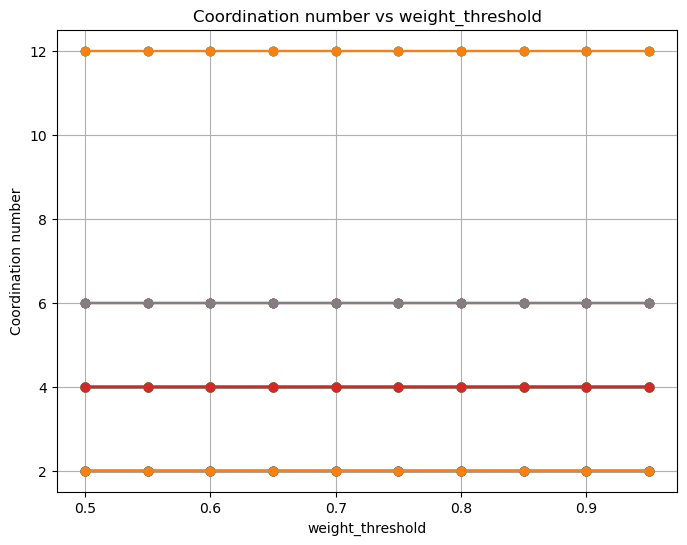

In [17]:
from pymatgen.analysis.local_env import CrystalNN
import numpy as np
import matplotlib.pyplot as plt

def scan_weight_threshold(structure, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.5, 0.95, 10)
    
    cnn = CrystalNN()
    n_sites = len(structure.sites)
    cn_matrix = np.zeros((n_sites, len(thresholds)), dtype=int)
    
    for i, w in enumerate(thresholds):
        for j, site in enumerate(structure.sites):
            nn_info = cnn.get_nn_info(structure, j)
            nn_info = [n for n in nn_info if n['weight'] >= w]
            cn_matrix[j, i] = len(nn_info)
    
    # 可视化配位数随阈值变化
    plt.figure(figsize=(8,6))
    for j in range(n_sites):
        plt.plot(thresholds, cn_matrix[j], marker='o', label=f"site {j}")
    plt.xlabel("weight_threshold")
    plt.ylabel("Coordination number")
    plt.title("Coordination number vs weight_threshold")
    plt.grid(True)
    plt.show()
    
    return thresholds, cn_matrix

# 使用示例
thresholds, cn_matrix = scan_weight_threshold(spinel_structure)


# 添加氧化态版本的crystalnn

In [8]:
def calculate_all_angles(center, neighbor_coords):
    vectors = neighbor_coords - center
    norms = np.linalg.norm(vectors, axis=1)
    dot = vectors @ vectors.T
    cos = dot / np.outer(norms, norms)
    cos = np.clip(cos, -1.0, 1.0)

    angles = np.degrees(np.arccos(cos))
    return angles


In [9]:
import numpy as np

def rms_deviation(values, ideal):
    """计算角度与理想值的 RMS 偏差"""
    values = np.array(values)
    ideal = np.array(ideal)
    return np.sqrt(np.mean((values - ideal)**2))


def classify_coordination(site, neighbors, angle_tolerance=15):
    """
    自动分类配位环境并判断是否扭曲
    返回:
        {
            'environment': str,
            'distorted': bool,
            'rms_angle_deviation': float
        }
    """

    n = len(neighbors)
    if n == 0:
        return {'environment': "isolated", 'distorted': False, 'rms_angle_deviation': 0}

    center = np.array(site.coords)
    neighbor_coords = np.array([nb["coords"] for nb in neighbors])
    angles = calculate_all_angles(center, neighbor_coords)
    angles_flat = np.round(angles[np.triu_indices(n, k=1)], 3)

    # -----------------------------
    # 理想角度模板库（可继续扩展）
    # -----------------------------
    ideal_geometries = {
        2:  {"linear": [180]},
        3:  {"trigonal_planar": [120, 120, 120]},
        4:  {
            "tetrahedral": [109.47] * 6,
            "square_planar": [90, 90, 90, 90, 180, 180]
        },
        5:  {
            "trigonal_bipyramidal": [90]*6 + [120]*3 + [180],
            "square_pyramidal": [90]*8 + [180]*2
        },
        6:  {
            "octahedral": [90]*12 + [180]*3
        },
        8:  {"cubic": [90]*12},
        12: {"cuboctahedral": [60]*12 + [90]*24}
    }

    # 配位数不在模板库 → 统称
    if n not in ideal_geometries:
        return {
            'environment': f"{n}-coordinated",
            'distorted': False,
            'rms_angle_deviation': 0
        }

    # -----------------------------
    # 自动匹配最佳环境
    # -----------------------------
    candidates = ideal_geometries[n]
    best_env = None
    best_rms = np.inf

    for env_name, ideal_angles in candidates.items():
        # 若角度数量不一致，按最接近填补
        target = np.array(ideal_angles)
        if len(target) != len(angles_flat):
            target = np.interp(
                np.linspace(0, 1, len(angles_flat)),
                np.linspace(0, 1, len(target)),
                target
            )

        rms = rms_deviation(angles_flat, target)
        if rms < best_rms:
            best_rms = rms
            best_env = env_name

    # -----------------------------
    # 扭曲判断：RMS 偏差大于阈值
    # -----------------------------
    distorted = best_rms > angle_tolerance

    return {
        'environment': best_env,
        'distorted': distorted,
        'rms_angle_deviation': float(best_rms)
    }

In [9]:
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.core import Structure
import numpy as np

def get_crystalnn_motifs(structure, symmetrized_structure, weight_threshold=0.8, angle_tolerance=15):
    """
    使用 CrystalNN (带氧化态修正) 生成结构基元。
    """

    try:
        # 使用 Pymatgen 的默认猜测算法
        # 如果你的结构比较复杂（如混合价态），这里可能会报错，需要手动指定
        if not structure[0].specie.oxidation_state: # 检查是否已有氧化态，避免重复添加
            structure.add_oxidation_state_by_guess()
            print("已自动为结构添加氧化态猜测。")
    except Exception as e:
        print(f"氧化态猜测失败: {e}")
        print("尝试使用 bond_valence 分析...")
        try:
            from pymatgen.analysis.bond_valence import BVAnalyzer
            bva = BVAnalyzer()
            structure = bva.get_oxi_state_decorated_structure(structure)
        except Exception as e2:
            raise ValueError(f"无法确定氧化态，CrystalNN 的 cation_anion 模式无法运行。错误: {e2}")

    # ==========================================
    # 步骤 2: 开启 cation_anion=True
    # ==========================================
    cnn = CrystalNN(cation_anion=True)
    
    motifs = []
    global_indices = set()


    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        
        # 这里的 group[0] 是原始结构原子，我们需要用索引去取带氧化态的新原子
        # 假设 symmetrized_structure 和 structure 索引是一一对应的
        original_site = group[0]

        for i, s in enumerate(structure):
             if s.distance(original_site) < 0.01: # 坐标重合
                 representative_index = i
                 break
        
        # 遍历该组所有等价原子
        for original_site_in_group in group:
            # 同样，通过坐标找回在新结构中的索引
            site_index = -1
            for i, s in enumerate(structure):
                if s.distance(original_site_in_group) < 0.01:
                    site_index = i
                    break
            
            if site_index == -1: continue # 理论上不应发生
            
            global_indices.add(site_index)
            site_with_oxi = structure[site_index] # 这是一个带氧化态的 Site 对象

            # 获取邻居信息 (此时 CrystalNN 会自动过滤掉同性电荷)
            nn_info = cnn.get_nn_info(structure, site_index)
            
            # 依然应用权重筛选，作为双重保险
            nn_info = [n for n in nn_info if n['weight'] >= weight_threshold]

            neighbors = []
            for n in nn_info:
                vector = n['site'].coords - site_with_oxi.coords
                neighbors.append({
                    'species': n['site'].species_string,
                    'coords': n['site'].coords,
                    'weight': n['weight'],
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index']
                })

            coord_info = classify_coordination(site_with_oxi, neighbors, angle_tolerance)
            
            motif = {
                'central_atom': {
                    'species': site_with_oxi.species_string, 
                    'coords': site_with_oxi.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': site_index,
                    'equivalent_group_index': group_idx,
                    'representative_index': representative_index
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'rms_angle_deviation': coord_info['rms_angle_deviation'],
                'neighbors': neighbors
            }
            motifs.append(motif)

    return motifs

In [10]:
# 生成基元
structural_motifs = get_crystalnn_motifs(
        spinel_structure, 
        symmetrized_structure, 
        weight_threshold=0.1,  # 可以在这里放宽一点权重，因为有了电荷修正，不再需要极高的权重来过滤
        angle_tolerance=15
    )
# 只提取等价组代表原子的基元做局部环境特征
representative_motifs = [
    m for m in structural_motifs
    if m['central_atom']['index'] == m['central_atom']['representative_index']
]

print(f"Total motifs: {len(structural_motifs)}")
print(f"Representative motifs: {len(representative_motifs)}")


氧化态猜测失败: Element has no attribute oxidation_state!
尝试使用 bond_valence 分析...


ValueError: 无法确定氧化态，CrystalNN 的 cation_anion 模式无法运行。错误: Valences cannot be assigned!

In [20]:

for i, m in enumerate(representative_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    # 输出每个 neighbor 的 species 和 index
    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

Motif 1: Cs+ (1b) CN=12 - cuboctahedral RMS=42.396° (distorted) | Neighbors count: {'I-': 12}
  Neighbor species & indices: [('I-', 2), ('I-', 4), ('I-', 3), ('I-', 2), ('I-', 4), ('I-', 3), ('I-', 3), ('I-', 4), ('I-', 2), ('I-', 4), ('I-', 2), ('I-', 3)]
  Central atom index: 0

Motif 2: Pb2+ (1a) CN=6 - octahedral RMS=46.476° (distorted) | Neighbors count: {'I-': 6}
  Neighbor species & indices: [('I-', 3), ('I-', 2), ('I-', 2), ('I-', 4), ('I-', 4), ('I-', 3)]
  Central atom index: 1

Motif 3: I- (3d) CN=6 - octahedral RMS=46.476° (distorted) | Neighbors count: {'Pb2+': 2, 'Cs+': 4}
  Neighbor species & indices: [('Pb2+', 1), ('Pb2+', 1), ('Cs+', 0), ('Cs+', 0), ('Cs+', 0), ('Cs+', 0)]
  Central atom index: 2



In [ ]:
#测试

In [14]:
target_idx = 48  # Motif 5 的中心原子
target_site = spinel_structure[target_idx]

print(f"=== 检查原子 {target_idx} ({target_site.species_string}) 的真实邻居 ===")

# 获取 5.0 Å 内的所有原子
neighbors_all = spinel_structure.get_neighbors(target_site, r=5.0)

# 按距离排序
neighbors_all.sort(key=lambda x: x.nn_distance)

print(f"{'Species':<10} {'Distance (Å)':<15} {'Index':<10}")
print("-" * 35)

for n in neighbors_all:
    # 打印物种、距离、和索引
    print(f"{n.species_string:<10} {n.nn_distance:.4f}           {n.index}")

try:
    idx_al1 = 24
    idx_al2 = 26

    angle = spinel_structure.get_angle(idx_al1, target_idx, idx_al2)
    print(f"\nAl({idx_al1}) - S({target_idx}) - Al({idx_al2}) 真实角度: {angle:.2f}°")
except:
    print("\n无法计算角度，请确认索引是否正确。")

=== 检查原子 48 (S) 的真实邻居 ===
Species    Distance (Å)    Index     
-----------------------------------
Al         2.2424           24
Al         2.2583           26
Ba         3.2946           7
S          3.4804           72
S          3.5146           43
Ba         3.6055           9
S          3.6063           46
Al         3.6099           18
S          3.6336           74
S          3.6830           66
S          3.6830           65
S          3.7013           50
S          3.7013           49
S          3.7947           44
Ba         3.8610           0
Al         4.3228           25
S          4.3774           77
Al         4.5581           17

Al(24) - S(48) - Al(26) 真实角度: 109.72°


# 补丁版本

In [9]:
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.core import Structure, Element
from pymatgen.analysis.bond_valence import BVAnalyzer 

def get_crystalnn_motifs_adaptive(structure, symmetrized_structure, weight_threshold=0.8, angle_tolerance=15):
    """
    CrystalNN + 动态自适应搜救补丁。
    氧化态策略：仅使用 'Guess' 和 'Bond Valence'，无手动硬编码。
    """
    # =========================================================================
    # 1. 氧化态处理
    # =========================================================================
    # 判断是否需要氧化态 (如果是 Element 对象则需要)
    need_oxidation = False
    try:
        if isinstance(structure[0].specie, Element):
            need_oxidation = True
    except: pass

    if need_oxidation:
        # --- 方案 A: 默认猜测 (基于化学式) ---
        try:
            structure.add_oxidation_state_by_guess()
            # print(">>> 方案A (Guess) 成功。")
        except Exception:
            # --- 方案 B: 键价分析 (基于几何结构) ---
            try:
                bva = BVAnalyzer()
                # BVA 返回新结构，必须覆盖原变量
                structure = bva.get_oxi_state_decorated_structure(structure)
                # print(">>> 方案A 失败，方案B (BVA) 成功。")
            except Exception as e_bva:
                # print(f">>> 方案A 和 方案B 均失败。将关闭电荷过滤。({e_bva})")
                pass

    # =========================================================================
    # 2. 最终状态检查
    # =========================================================================
    try:
        _ = structure[0].specie.oxi_state
        use_charge = True
    except AttributeError:
        use_charge = False

    cnn = CrystalNN(cation_anion=use_charge)
    motifs = []
    
    # 关键参数
    MAX_SEARCH_RADIUS = 6.0 
    DYNAMIC_TOLERANCE = 0.6  

    # === 外层循环：遍历不等价组 ===
    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        
        # 找组代表索引 (用于标记)
        representative_site = group[0]
        representative_index = -1
        for i, s in enumerate(structure):
             if s.distance(representative_site) < 0.01:
                 representative_index = i
                 break
        if representative_index == -1: continue

        # === 内层循环：遍历组内原子 ===
        for original_site_in_group in group:
            
            # 找当前原子索引
            site_index = -1
            for i, s in enumerate(structure):
                if s.distance(original_site_in_group) < 0.01:
                    site_index = i
                    break
            if site_index == -1: continue
            
            site_with_oxi = structure[site_index]
            
            # --- Part A: CrystalNN 基础层 ---
            nn_info = cnn.get_nn_info(structure, site_index)
            nn_info = [n for n in nn_info if n['weight'] >= weight_threshold]

            neighbors = []
            existing_coords = [] 

            for n in nn_info:
                vector = n['site'].coords - site_with_oxi.coords
                existing_coords.append(n['site'].coords)
                neighbors.append({
                    'species': n['site'].species_string,
                    'coords': n['site'].coords,
                    'weight': n['weight'],
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index']
                })

            # --- Part B: 动态自适应补丁 ---
            candidate_neighbors = structure.get_neighbors(site_with_oxi, MAX_SEARCH_RADIUS)
            
            try:
                r_center = site_with_oxi.specie.element.atomic_radius
                if r_center is None: r_center = 1.5
            except: r_center = 1.5

            for dn in candidate_neighbors:
                # 1. 坐标查重
                is_duplicate = False
                for exist_c in existing_coords:
                    if np.linalg.norm(dn.coords - exist_c) < 1e-4:
                        is_duplicate = True
                        break
                if is_duplicate: continue
                
                # 2. 电荷过滤 (如果有的话)
                if use_charge:
                    try:
                        c_oxi = site_with_oxi.specie.oxi_state
                        n_oxi = dn.specie.oxi_state
                        if c_oxi * n_oxi > 0: continue
                    except: pass 

                # 3. 动态截断
                try:
                    r_neighbor = dn.specie.element.atomic_radius
                    if r_neighbor is None: r_neighbor = 1.5
                except: r_neighbor = 1.5
                
                limit = r_center + r_neighbor + DYNAMIC_TOLERANCE
                
                if dn.nn_distance <= limit:
                    vector = dn.coords - site_with_oxi.coords
                    neighbors.append({
                        'species': dn.species_string,
                        'coords': dn.coords,
                        'weight': 1.0, 
                        'distance': dn.nn_distance,
                        'vector': vector,
                        'index': dn.index
                    })
                    existing_coords.append(dn.coords)

            # --- Part C: 输出 ---
            coord_info = classify_coordination(site_with_oxi, neighbors, angle_tolerance)
            
            motif = {
                'central_atom': {
                    'species': site_with_oxi.species_string,
                    'coords': site_with_oxi.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': site_index,
                    'equivalent_group_index': group_idx,
                    'representative_index': representative_index
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'rms_angle_deviation': coord_info['rms_angle_deviation'],
                'neighbors': neighbors
            }
            motifs.append(motif)

    return motifs

# 补丁版本2

In [18]:
import math
import numpy as np
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

def get_crystalnn_motifs_adaptive(structure, symmetrized_structure=None, weight_threshold=0.8, angle_tolerance=15):
    """
    自适应 CrystalNN 配位环境分析函数 (包含几何遮蔽补救措施)
    
    逻辑链条：
    1. 检查现有氧化态 -> 有则用。
    2. 无氧化态 -> 用 add_oxidation_state_by_guess (几何/组分猜测) -> 成功则用。
    3. 猜测失败 -> 清除氧化态 -> 强制启用 cation_anion=True (触发 CrystalNN 的电负性兜底)。
    4. 补救逻辑 (Rescuing Logic) -> 针对几何遮蔽效应进行基于半径的补偿，但加入电负性门控以防误判。
    """

    # =========================================================================
    #  0. 结构预处理 (Z-Check & Size-Check)
    # =========================================================================
    
    # 0.1 Z-Check (原胞检查)
    sga_pre = SpacegroupAnalyzer(structure, symprec=0.01)
    try:
        primitive_structure = sga_pre.get_primitive_standard_structure()
        if structure.num_sites > primitive_structure.num_sites:
            print(f"⚠️ [Z-Check] 转换为原胞 ({structure.num_sites} -> {primitive_structure.num_sites} atoms)")
            working_structure = primitive_structure
            symmetrized_structure = None 
        else:
            working_structure = structure.copy()
    except Exception as e:
        print(f"⚠️ [Z-Check] 原胞转换失败，使用原始结构: {e}")
        working_structure = structure.copy()

    # 0.2 Size-Check (扩胞，保证 Voronoi 算法在 PBC 下的稳定性)
    MIN_LATTICE_SIZE = 10.0
    min_lat = min(working_structure.lattice.abc)
    is_expanded = False
    if min_lat < MIN_LATTICE_SIZE:
        scaling = [
            math.ceil(MIN_LATTICE_SIZE / working_structure.lattice.a),
            math.ceil(MIN_LATTICE_SIZE / working_structure.lattice.b),
            math.ceil(MIN_LATTICE_SIZE / working_structure.lattice.c)
        ]
        print(f"[Size-Check] 物理扩胞 scaling={scaling}")
        working_structure.make_supercell(scaling)
        is_expanded = True
    
    # 获取对称性分析结果
    if is_expanded or symmetrized_structure is None:
        sga = SpacegroupAnalyzer(working_structure)
        symmetrized_structure = sga.get_symmetrized_structure()

    # =========================================================================
    #  1. 氧化态处理策略 (The 3 Strategies)
    # =========================================================================
    
    try:
        # --- Strategy 1: 检查现有氧化态 ---
        # 只要能读出 oxi_state 且不全为 0，就认为有效
        if working_structure[0].specie.oxi_state != 0:
            print("✅ [Strategy 1] 检测到现有氧化态，直接使用。")
        else:
            raise AttributeError # 只有0价，跳到步骤2
            
    except AttributeError:
        # --- Strategy 2: 几何/组分猜测 ---
        try:
            working_structure.add_oxidation_state_by_guess()
            print("✅ [Strategy 2] 几何/组分猜测氧化态成功。")
            
        except Exception as e:
            # --- Strategy 3: 电负性兜底 ---
            working_structure.remove_oxidation_states()
            print("⚠️ [Strategy 3] 氧化态猜测失败。")
            print("   -> 将传递无氧化态结构给 CrystalNN。")
            print("   -> CrystalNN 将自动退回【电负性差异】判断模式。")
    
    # =========================================================================
    #  2. CrystalNN 主计算与补救逻辑
    # =========================================================================

    # 始终开启 cation_anion=True
    # 有氧化态时 -> 严格电荷排斥
    # 无氧化态时 -> 电负性差异排斥
    cnn = CrystalNN(cation_anion=True) 
    
    motifs = []
    
    # 定义补救逻辑的参数
    # MAX_SEARCH_RADIUS: 搜索候选邻居的最大范围
    # RESCUE_TOLERANCE: 补救时的距离宽容度 (比 JmolNN 的 0.45 略紧，以防误判)
    # MIN_ELECTRONEG_DIFF: 电负性差异门控阈值 (用于 Strategy 3)
    MAX_SEARCH_RADIUS = 6.0
    RESCUE_TOLERANCE = 0.5 
    MIN_ELECTRONEG_DIFF = 0.5 

    # 辅助函数：清洗元素符号 (去除氧化态数字，如 "Fe2+" -> "Fe")
    def clean_sp(species_obj):
        return "".join([c for c in str(species_obj) if c.isalpha()])

    # 遍历 Wyckoff 等效位置组
    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        representative_site_obj = group[0]
        
        # 找到代表原子在 working_structure 中的索引
        rep_index = -1
        for i, s in enumerate(working_structure):
             if s.distance(representative_site_obj) < 0.001:
                rep_index = i
                break
        
        # 遍历该组中的每个原子 (处理扩胞后的情况)
        for target_site_obj in group:
            current_index = -1
            for i, s in enumerate(working_structure):
                if s.distance(target_site_obj) < 0.001:
                    current_index = i
                    break
            if current_index == -1: continue

            site_with_oxi = working_structure[current_index]

            # --- A. 标准 CrystalNN 计算 ---
            try:
                nn_info = cnn.get_nn_info(working_structure, current_index)
            except Exception:
                nn_info = []
            
            # 根据权重筛选
            nn_info = [n for n in nn_info if n['weight'] >= weight_threshold]
            
            neighbors = []
            existing_coords = [] # 用于去重
            
            for n in nn_info:
                clean_species_str = clean_sp(n['site'].specie)
                vector = n['site'].coords - site_with_oxi.coords
                neighbors.append({
                    'species': clean_species_str,
                    'coords': n['site'].coords,
                    'weight': n['weight'],
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index']
                })
                existing_coords.append(n['site'].coords)

            # --- B. Rescuing Logic (针对几何遮蔽的补救措施) ---
            # 解决如 BaAl2S4 中 S 原子看不见 Ba 原子的物理失效
            
            candidate_neighbors = working_structure.get_neighbors(site_with_oxi, MAX_SEARCH_RADIUS)
            r_center = getattr(site_with_oxi.specie, "atomic_radius", 1.5) or 1.5
            
            # 获取中心原子的电负性 (用于 Strategy 3 的门控)
            neg_center = 0
            if hasattr(site_with_oxi.specie, "X"):
                neg_center = site_with_oxi.specie.X

            for dn in candidate_neighbors:
                # B.1: 几何去重
                is_duplicate = False
                for exist_c in existing_coords:
                    if np.linalg.norm(dn.coords - exist_c) < 1e-4:
                        is_duplicate = True; break
                if is_duplicate: continue

                # B.2: 化学合理性门控 (Chemical Gating) - 核心修正部分!
                should_skip = False
                try:
                    # [Case 1 & 2]: 有氧化态 -> 严格遵守电荷排斥
                    # 如果电荷符号相同 (乘积 > 0)，则是同性排斥，坚决不救
                    if site_with_oxi.specie.oxi_state * dn.specie.oxi_state > 0: 
                        should_skip = True
                except AttributeError:
                    # [Case 3]: 无氧化态 -> 启用“电负性门控”
                    # 风险：在无氧化态时，单纯的距离判断会把 Al-Al 或 Na-K 误判为成键
                    # 修正：只有当电负性差异足够大 (暗示离子/极性相互作用) 时，才允许几何补救
                    try:
                        neg_neighbor = dn.specie.X
                        diff = abs(neg_center - neg_neighbor)
                        
                        # 如果电负性差异太小 (如 < 0.5)，认为是金属键或同类原子聚集，不予补救
                        # 对于 Ba-S (diff ~ 1.7) -> Pass
                        # 对于 Al-Al (diff = 0) -> Skip
                        if diff < MIN_ELECTRONEG_DIFF: 
                            should_skip = True
                    except:
                        # 缺少电负性数据，保守跳过
                        should_skip = True
                
                if should_skip: continue

                # B.3: 物理距离判定 (JmolNN-style)
                r_neighbor = getattr(dn.specie, "atomic_radius", 1.5) or 1.5
                limit = r_center + r_neighbor + RESCUE_TOLERANCE
                
                if dn.nn_distance <= limit:
                    clean_species_str = clean_sp(dn.specie)
                    vector = dn.coords - site_with_oxi.coords
                    
                    # 添加被救回的邻居
                    # 注意：赋予 weight=1.0 可能会在某些畸变分析中引入偏差，
                    # 但为了修正配位数 (CN)，这是必要的权衡。
                    neighbors.append({
                        'species': clean_species_str,
                        'coords': dn.coords,
                        'weight': 1.0,  # 强制赋予高权重
                        'distance': dn.nn_distance,
                        'vector': vector,
                        'index': dn.index,
                        'is_rescued': True # 标记以便后续追踪
                    })
                    existing_coords.append(dn.coords)

            # --- C. 配位构型分类 ---
            try:
                # 尝试调用外部定义的分类函数
                coord_info = classify_coordination(site_with_oxi, neighbors, angle_tolerance)
            except NameError:
                # 优雅降级：如果没有定义分类函数，只返回基础信息
                coord_info = {'environment': 'Unknown', 'distorted': False, 'rms_angle_deviation': 0}
            except Exception:
                coord_info = {'environment': 'Error', 'distorted': False, 'rms_angle_deviation': 0}

            center_clean_species = clean_sp(site_with_oxi.specie)

            motif = {
                'central_atom': {
                    'species': center_clean_species,
                    'coords': site_with_oxi.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': current_index, 
                    'representative_index': rep_index,
                    'group_id': group_idx,
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'neighbors': neighbors
            }
            motifs.append(motif)

    # 返回纯净的结构副本 (移除氧化态，以免影响后续流程)
    clean_return_structure = working_structure.copy()
    clean_return_structure.remove_oxidation_states()

    return motifs, clean_return_structure

# 版本三

In [12]:
from pymatgen.core.periodic_table import Element
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
import math
def get_crystalnn_motifs_adaptive(structure, symmetrized_structure=None, weight_threshold=0.8, angle_tolerance=15):

    working_structure = structure.copy()
    
    # --- 0. 预处理策略 (User Requested Logic) ---

    try:
        sga_check = SpacegroupAnalyzer(working_structure, symprec=0.01)
        primitive_structure = sga_check.get_primitive_standard_structure()
        
        num_atoms_current = working_structure.num_sites
        num_atoms_primitive = primitive_structure.num_sites

        if num_atoms_current == num_atoms_primitive:
            print(f"ℹ️ [Check] 检测到输入为原胞 ({num_atoms_current} atoms)，准备执行扩胞以稳定 CrystalNN...")

            MIN_LATTICE_SIZE = 10.0

            scaling = [math.ceil(MIN_LATTICE_SIZE / l) for l in working_structure.lattice.abc]

            if any(s > 1 for s in scaling):
                print(f"[Supercell] 执行物理扩胞: {scaling}")
                working_structure.make_supercell(scaling)
                symmetrized_structure = None # 结构改变，重置对称性
            else:
                print(f"[Check] 原胞尺寸足够大 (>{MIN_LATTICE_SIZE}Å)，无需扩胞。")
                
        else:
            print(f"[Check] 检测到输入为超胞 ({num_atoms_current} > {num_atoms_primitive} atoms)，保持原样。")

    except Exception as e:
        print(f"[Check] 对称性分析或原胞判定失败 ({e})，使用原始结构继续。")

    # 0.3 重新计算对称性 (如果扩胞了，或者传入时为 None)
    if symmetrized_structure is None:
        sga = SpacegroupAnalyzer(working_structure)
        symmetrized_structure = sga.get_symmetrized_structure()

    # --- 1. 氧化态策略 ---
    try:
        if working_structure[0].specie.oxi_state == 0: raise AttributeError
    except AttributeError:
        try:
            working_structure.add_oxidation_state_by_guess()
        except:
            working_structure.remove_oxidation_states()

    # --- 辅助函数 ---
    def clean_sp(s): return "".join([c for c in str(s) if c.isalpha()])
    def get_robust_radius(site):
        try:
            el = Element(site.specie.symbol)
            r = el.atomic_radius_calculated or el.atomic_radius
            if r is None: return 1.35
            return float(r)
        except: return 1.35

    # --- 2. CrystalNN 初始化 ---
    cnn = CrystalNN(cation_anion=True)
    motifs = []
    MAX_SEARCH_RADIUS = 6.0
    RESCUE_TOLERANCE = 1.5
    MIN_ELECTRONEG_DIFF = 0.5

    # --- 3. 遍历 Wyckoff 组 ---
    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        representative_site_obj = group[0]

        # 查找代表原子索引
        rep_index = -1
        for i, s in enumerate(working_structure):
            if s.distance(representative_site_obj) < 0.001: rep_index = i; break
        
        # 遍历组内原子
        for target_site_obj in group:
            current_index = -1
            for i, s in enumerate(working_structure):
                if s.distance(target_site_obj) < 0.001: current_index = i; break
            if current_index == -1: continue

            site_with_oxi = working_structure[current_index]
            r_center = get_robust_radius(site_with_oxi)

            # CrystalNN 计算
            try: nn_info = cnn.get_nn_info(working_structure, current_index)
            except: nn_info = []

            neighbors = []
            found_indices = set()

            for n in [x for x in nn_info if x['weight'] >= weight_threshold]:
                vector = n['site'].coords - site_with_oxi.coords
                neighbors.append({
                    'species': clean_sp(n['site'].specie),
                    'coords': n['site'].coords,
                    'weight': n['weight'],
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index'],
                    'is_rescued': False
                })
                found_indices.add(n['site_index'])

            min_existing_weight = min([n['weight'] for n in neighbors]) if neighbors else 1.0

            # 补救逻辑
            candidate_neighbors = working_structure.get_neighbors(site_with_oxi, MAX_SEARCH_RADIUS)
            neg_center = getattr(site_with_oxi.specie, "X", 0)

            for dn in candidate_neighbors:
                if dn.index in found_indices or dn.nn_distance < 0.1: continue
                should_skip = False
                try:
                    if site_with_oxi.specie.oxi_state * dn.specie.oxi_state > 0: should_skip = True
                except:
                    try:
                        if abs(neg_center - getattr(dn.specie, "X", 0)) < MIN_ELECTRONEG_DIFF: should_skip = True
                    except: should_skip = True
                if should_skip: continue

                limit = r_center + get_robust_radius(dn) + RESCUE_TOLERANCE
                if dn.nn_distance <= limit:
                    decay = max(0.1, 1.0 - (dn.nn_distance / (limit + 0.1)) ** 2)
                    neighbors.append({
                        'species': clean_sp(dn.specie),
                        'coords': dn.coords,
                        'weight': float(f"{min(0.5, min_existing_weight * 0.9) * decay:.4f}"),
                        'distance': dn.nn_distance,
                        'vector': dn.coords - site_with_oxi.coords,
                        'index': dn.index,
                        'is_rescued': True
                    })
                    found_indices.add(dn.index)

            # 结果打包
            coord_info = classify_coordination(site_with_oxi, neighbors, angle_tolerance)
            motif = {
                'central_atom': {
                    'species': clean_sp(site_with_oxi.specie),
                    'coords': site_with_oxi.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': current_index,
                    'representative_index': rep_index,
                    'group_id': group_idx,
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'rms_angle_deviation': coord_info['rms_angle_deviation'],
                'neighbors': sorted(neighbors, key=lambda x: x['distance'])
            }
            motifs.append(motif)

    clean_ret = working_structure.copy()
    clean_ret.remove_oxidation_states()
    return motifs, clean_ret

# 参数不多版本

In [10]:
import math
from pymatgen.core.periodic_table import Element
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.bond_valence import BVAnalyzer 

def clean_sp(s): return "".join([c for c in str(s) if c.isalpha()])

def get_crystalnn_motifs_adaptive(structure, symmetrized_structure=None, weight_threshold=0.3, angle_tolerance=15, fallback_radius=4.0):
    """
    Args:
        fallback_radius (float): 当原子配位数为0时，直接在这个半径内强制搜索邻居。  默认为 4.0 Å。
    """
    
    working_structure = structure.copy()
    n_sites = len(working_structure)
    print(f"-> [Step 0] 预处理: 原子数 {n_sites}")

    # === 0. 扩胞检测 ===
    try:
        sga_check = SpacegroupAnalyzer(working_structure, symprec=0.01)
        prim = sga_check.get_primitive_standard_structure()
        if working_structure.num_sites == prim.num_sites:
            scaling = [math.ceil(9.0 / l) for l in working_structure.lattice.abc]
            if any(s > 1 for s in scaling):
                working_structure.make_supercell(scaling)
                symmetrized_structure = None 
                n_sites = len(working_structure) 
    except: pass

    # === 1. 氧化态计算 ===
    try:
        bva = BVAnalyzer()
        working_structure = bva.get_oxi_state_decorated_structure(working_structure)
    except:
        try: working_structure.add_oxidation_state_by_guess()
        except: working_structure.remove_oxidation_states()

    # === 2. Phase 1: CrystalNN 标准筛选 ===
    cnn = CrystalNN(cation_anion=True, x_diff_weight=0.0)
    edge_weights = {}
    raw_adjacency = {i: set() for i in range(n_sites)}

    print("-> [Step 2] Phase 1: 标准拓扑扫描...")
    for i in range(n_sites):
        center = working_structure[i]
        
        # A. 运行 CrystalNN
        try: nn_info = cnn.get_nn_info(working_structure, i)
        except: nn_info = []

        # B. 收集强邻居
        valid_neighbors_ref = [] 
        for n in nn_info:
            if n['weight'] > 0:
                # 只要有权重，先存个档作为参考
                d = working_structure[n['site_index']].distance(center)
                valid_neighbors_ref.append({'dist': d, 'weight': n['weight']})
                
                # 只有大于阈值的才算正式邻居
                if n['weight'] >= weight_threshold:
                    n_idx = n['site_index']
                    raw_adjacency[i].add(n_idx)
                    edge_weights[(i, n_idx)] = n['weight']

        # C. (可选) 内填 - 这一步你觉得不全可以跳过，主要靠 Phase 2 兜底
        # 这里保留一个极小的修正 (Max * 1.05)，仅用于修补数值误差
        if nn_info:
             # 这里不做激进的内填了，因为我们要把控制权交给 Phase 2
             pass

    # =================================================================
    # Phase 2: [绝对截断兜底] 
    # 只要 CN=0，直接搜索 fallback_radius 范围内的所有原子
    # =================================================================
    print(f"-> [Step 3] Phase 2: 检查孤立原子 (强制半径 {fallback_radius} Å)...")
    
    for i in range(n_sites):
        # 如果 Phase 1 没找到任何邻居 (CN=0)
        if len(raw_adjacency[i]) == 0:
            center = working_structure[i]
            
            # 1. 直接搜索 fallback_radius 范围内的所有原子
            candidates = working_structure.get_neighbors(center, fallback_radius)
            
            # 排除自己和极短距离噪点
            candidates = [c for c in candidates if c.nn_distance > 0.1]
            candidates.sort(key=lambda x: x.nn_distance)
            
            if candidates:
                # 为了计算权重的归一化，我们需要知道最近邻距离
                d_min = candidates[0].nn_distance
                
                # 2. 强制加入所有在该半径内的原子
                for cand in candidates:
                    n_idx = cand.index
                    raw_adjacency[i].add(n_idx)
                    
                    # 3. 赋予权重
                    # 即使是强制截断，我们也给近的原子大权重，远的原子小权重
                    w = math.exp(1.0 - (cand.nn_distance / d_min))
                    # 限制最大权重为 0.5 (表示这是兜底来的，不是亲生的)
                    edge_weights[(i, n_idx)] = float(f"{w * 0.5:.4f}")
            else:
                print(f" 原子 {i} ({center.specie}) 在 {fallback_radius} Å 内真的是孤立的。")

    # === 3. 全局对称化 (Phase 3) ===
    print("-> [Step 4] Phase 3: 全局对称化...")
    final_adjacency = {i: set() for i in range(n_sites)}
    
    for i in range(n_sites):
        for n_idx in raw_adjacency[i]:
            final_adjacency[i].add(n_idx)
            # 强制双向
            if i not in final_adjacency[n_idx]:
                final_adjacency[n_idx].add(i)
                # 权重镜像
                if (i, n_idx) in edge_weights:
                    edge_weights[(n_idx, i)] = edge_weights[(i, n_idx)]
                else:
                    edge_weights[(n_idx, i)] = 0.05

    # === 4. 特征提取 ===
    print("-> [Step 5] 生成特征...")
    
    rep_mapping = {}
    wyckoff_map = {}
    group_id_map = {}
    
    try:
        sga = SpacegroupAnalyzer(working_structure, symprec=0.01)
        symm = sga.get_symmetrized_structure()
        for gid, indices in enumerate(symm.equivalent_indices):
            rep = indices[0]
            sym = symm.wyckoff_symbols[gid]
            for idx in indices:
                rep_mapping[idx] = rep
                wyckoff_map[idx] = sym
                group_id_map[idx] = gid
    except:
        for i in range(n_sites): rep_mapping[i]=i; wyckoff_map[i]='a'; group_id_map[i]=i

    motifs = []
    for i in range(n_sites):
        center = working_structure[i]
        neighbors = []
        for n_idx in final_adjacency[i]:
            n_site = working_structure[n_idx]
            dist = center.distance(n_site)
            vec = n_site.coords - center.coords
            w = edge_weights.get((i, n_idx), 0.0)
            
            neighbors.append({
                'species': clean_sp(n_site.specie), 
                'coords': n_site.coords,
                'weight': w, 
                'distance': dist, 
                'vector': vec, 
                'index': n_idx, 
                'is_rescued': False
            })
        
        coord = classify_coordination(center, neighbors, angle_tolerance)
        
        motif = {
            'central_atom': {
                'species': clean_sp(center.specie), 
                'coords': center.frac_coords,
                'index': i, 
                'representative_index': rep_mapping.get(i, i),
                'wyckoff': wyckoff_map.get(i, 'a'), 
                'group_id': group_id_map.get(i, 0),
                'oxi_state': getattr(center.specie, "oxi_state", 0)
            },
            'coordination_number': len(neighbors),
            'coordination_environment': coord['environment'],
            'distorted': coord['distorted'],
            'rms_angle_deviation': coord['rms_angle_deviation'],
            'neighbors': sorted(neighbors, key=lambda x: x['distance'])
        }
        motifs.append(motif)

    clean_ret = working_structure.copy()
    clean_ret.remove_oxidation_states()
    return motifs, clean_ret

In [11]:
# 生成基元
structural_motifs, structure = get_crystalnn_motifs_adaptive(
        spinel_structure,
        None,         
        weight_threshold=0.6
    )
# 只提取等价组代表原子的基元做局部环境特征
representative_motifs = [
    m for m in structural_motifs
    if m['central_atom']['index'] == m['central_atom']['representative_index']
]

print(f"Total motifs: {len(structural_motifs)}")
print(f"Representative motifs: {len(representative_motifs)}")


-> [Step 0] 预处理: 原子数 36
-> [Step 2] Phase 1: 标准拓扑扫描...
-> [Step 3] Phase 2: 检查孤立原子 (强制半径 4.0 Å)...
-> [Step 4] Phase 3: 全局对称化...
-> [Step 5] 生成特征...
Total motifs: 36
Representative motifs: 3


In [12]:
for i, m in enumerate(representative_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

Motif 1: K (8c) CN=12 - cuboctahedral RMS=34.586° (distorted) | Neighbors count: {'F': 12}
  Neighbor species & indices: [('F', 32), ('F', 25), ('F', 33), ('F', 14), ('F', 17), ('F', 21), ('F', 22), ('F', 23), ('F', 24), ('F', 12), ('F', 16), ('F', 19)]
  Central atom index: 0

Motif 2: Ni (4a) CN=6 - octahedral RMS=65.727° (distorted) | Neighbors count: {'F': 6}
  Neighbor species & indices: [('F', 12), ('F', 16), ('F', 20), ('F', 35), ('F', 15), ('F', 19)]
  Central atom index: 8

Motif 3: F (24e) CN=5 - trigonal_bipyramidal RMS=63.760° (distorted) | Neighbors count: {'Ni': 1, 'K': 4}
  Neighbor species & indices: [('Ni', 8), ('K', 1), ('K', 4), ('K', 5), ('K', 0)]
  Central atom index: 12



In [31]:
for i, m in enumerate(structural_motifs):
    neighbor_species = [n['species'] for n in m['neighbors']]
    species_count = {s: neighbor_species.count(s) for s in set(neighbor_species)}

    neighbor_indices = [(n['species'], n['index']) for n in m['neighbors']]

    # 获取 RMS 值
    rms = m.get('rms_angle_deviation', 0.0)

    print(f"Motif {i+1}: {m['central_atom']['species']} ({m['central_atom']['wyckoff']}) "
          f"CN={m['coordination_number']} - {m['coordination_environment']} "
          f"RMS={rms:.3f}° "  # <--- 新增输出 RMS 角度偏差
          f"{'(distorted)' if m['distorted'] else ''} | Neighbors count: {species_count}")
    
    print(f"  Neighbor species & indices: {neighbor_indices}")
    print(f"  Central atom index: {m['central_atom']['index']}\n")

Motif 1: Ba (8a) CN=6 - octahedral RMS=65.727° (distorted) | Neighbors count: {'O': 6}
  Neighbor species & indices: [('O', 32), ('O', 16), ('O', 24), ('O', 34), ('O', 20), ('O', 25)]
  Central atom index: 0

Motif 2: Ba (8a) CN=6 - octahedral RMS=46.476° (distorted) | Neighbors count: {'O': 6}
  Neighbor species & indices: [('O', 25), ('O', 33), ('O', 17), ('O', 24), ('O', 35), ('O', 21)]
  Central atom index: 1

Motif 3: Ba (8a) CN=6 - octahedral RMS=65.727° (distorted) | Neighbors count: {'O': 6}
  Neighbor species & indices: [('O', 34), ('O', 32), ('O', 26), ('O', 18), ('O', 22), ('O', 27)]
  Central atom index: 2

Motif 4: Ba (8a) CN=6 - octahedral RMS=46.476° (distorted) | Neighbors count: {'O': 6}
  Neighbor species & indices: [('O', 35), ('O', 26), ('O', 27), ('O', 33), ('O', 19), ('O', 23)]
  Central atom index: 3

Motif 5: Ba (8a) CN=6 - octahedral RMS=65.727° (distorted) | Neighbors count: {'O': 6}
  Neighbor species & indices: [('O', 20), ('O', 36), ('O', 16), ('O', 28), ('

voronoi

In [17]:
from pymatgen.analysis.local_env import VoronoiNN
import numpy as np

def get_voronoi_motifs(structure, symmetrized_structure, angle_tolerance=15, weight_threshold=0.01):
    """
    使用 VoronoiNN 生成结构基元（每个原子都生成），标记等价组和代表原子。
    """
    vnn = VoronoiNN(tol=0.01)  
    motifs = []
    global_indices = set()

    for group_idx, group in enumerate(symmetrized_structure.equivalent_sites):
        wyckoff_symbol = symmetrized_structure.wyckoff_symbols[group_idx]
        representative_index = structure.sites.index(group[0])

        for site in group:
            site_index = structure.sites.index(site)
            global_indices.add(site_index)

            nn_info = vnn.get_nn_info(structure, site_index)
            nn_info = [n for n in nn_info if n.get('weight', 1.0) >= weight_threshold]

            neighbors = []
            for n in nn_info:
                vector = n['site'].coords - site.coords
                neighbors.append({
                    'species': n['site'].species_string,
                    'coords': n['site'].coords,
                    'weight': n.get('weight', 1.0),
                    'distance': np.linalg.norm(vector),
                    'vector': vector,
                    'index': n['site_index']
                })

            coord_info = classify_coordination(site, neighbors, angle_tolerance)

            motif = {
                'central_atom': {
                    'species': site.species_string,
                    'coords': site.frac_coords,
                    'wyckoff': wyckoff_symbol,
                    'index': site_index,
                    'equivalent_group_index': group_idx,
                    'representative_index': representative_index
                },
                'coordination_number': len(neighbors),
                'coordination_environment': coord_info['environment'],
                'distorted': coord_info['distorted'],
                'neighbors': neighbors
            }
            motifs.append(motif)

    all_indices = set(range(len(structure.sites)))
    missing_indices = all_indices - global_indices
    if missing_indices:
        print(f"Warning: the following atoms were not included as centers: {missing_indices}")

    return motifs


In [18]:
structural_motifs_vnn = get_voronoi_motifs(
    spinel_structure,
    symmetrized_structure,
    angle_tolerance=15,
    weight_threshold=0.5
)

# 只取每组代表原子基元做局部环境特征
representative_motifs = [
    m for m in structural_motifs_vnn
    if m['central_atom']['index'] == m['central_atom']['representative_index']
]

print(f"Total motifs: {len(structural_motifs_vnn)}")
print(f"Representative motifs: {len(representative_motifs)}")

Total motifs: 56
Representative motifs: 8


In [11]:
motif_data = []

for m in structural_motifs_vnn:
    central = m['central_atom']
    neighbors = m['neighbors']

    species_count = {}
    for n in neighbors:
        species_count[n['species']] = species_count.get(n['species'], 0) + 1

    neighbor_info = [(n['species'], n['index'], np.linalg.norm(np.array(n['coords']) - np.array(central['coords']))) 
                     for n in neighbors]

    motif_data.append({
        'central_species': central['species'],
        'wyckoff': central['wyckoff'],
        'central_index': central['index'],
        'coordination_number': m['coordination_number'],
        'coordination_environment': m['coordination_environment'],
        'distorted': m['distorted'],
        'neighbor_count_by_species': species_count,
        'neighbor_details': neighbor_info
    })
print(motif_data[0])

{'central_species': 'Cu', 'wyckoff': '12b', 'central_index': 0, 'coordination_number': 4, 'coordination_environment': 'square_planar', 'distorted': False, 'neighbor_count_by_species': {'O': 4}, 'neighbor_details': [('O', 34, 8.00491811766507), ('O', 49, 6.3923822115757005), ('O', 28, 9.979186787656106), ('O', 50, 9.133901423208236)]}


In [23]:

def recommend_voronoi_threshold(structural_motifs, thresholds=None):
    """
    根据 VoronoiNN 权重和 CN 变化自动推荐 weight_threshold

    Args:
        structural_motifs: VoronoiNN 提取的结构基元列表
        thresholds: 可选，扫描的阈值列表

    Returns:
        recommended_threshold: 推荐的 weight_threshold
        cn_dict: 每个阈值对应的 CN 列表
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 1.0, 50)

    # 收集所有邻居权重
    all_weights = []
    for m in structural_motifs:
        for n in m['neighbors']:
            all_weights.append(n['weight'])
    all_weights = np.array(all_weights)

    # 绘制权重直方图
    plt.figure(figsize=(6,4))
    plt.hist(all_weights, bins=50, color='skyblue', edgecolor='k')
    plt.xlabel('Voronoi Neighbor Weight')
    plt.ylabel('Count')
    plt.title('Distribution of Voronoi Neighbor Weights')
    plt.show()

    # 统计每个阈值下 CN
    cn_dict = defaultdict(list)
    avg_cns = []

    for th in thresholds:
        CNs = []
        for m in structural_motifs:
            neighbors = [n for n in m['neighbors'] if n['weight'] >= th]
            CNs.append(len(neighbors))
        cn_dict[th] = CNs
        avg_cns.append(np.mean(CNs))

    # 绘制阈值 vs 平均 CN 曲线
    plt.figure(figsize=(6,4))
    plt.plot(thresholds, avg_cns, '-o', color='orange')
    plt.xlabel('weight_threshold')
    plt.ylabel('Average CN')
    plt.title('Average CN vs Weight Threshold')
    plt.grid(True)
    plt.show()

    # 自动推荐阈值：选择 CN 仍然稳定且刚好在权重断层前
    # 方法：找到第一个平均 CN 降低明显的位置之前的阈值
    avg_cns = np.array(avg_cns)
    diffs = -np.diff(avg_cns)  # CN下降量
    significant_drop_idx = np.where(diffs > 0.1)[0]  # CN下降明显
    if len(significant_drop_idx) > 0:
        recommended_threshold = thresholds[significant_drop_idx[0]]
    else:
        # 如果没有明显下降，选择 CN 接近最大值的阈值
        recommended_threshold = thresholds[np.argmax(avg_cns)]

    print(f"Recommended weight_threshold: {recommended_threshold:.3f}")
    return recommended_threshold, cn_dict


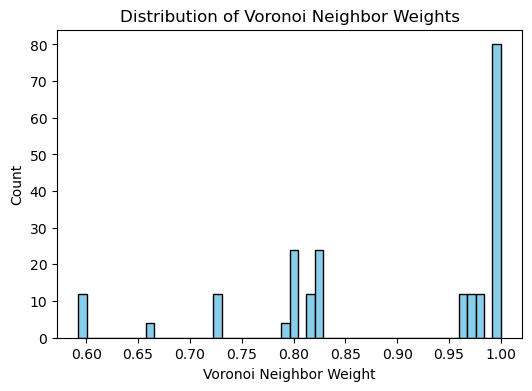

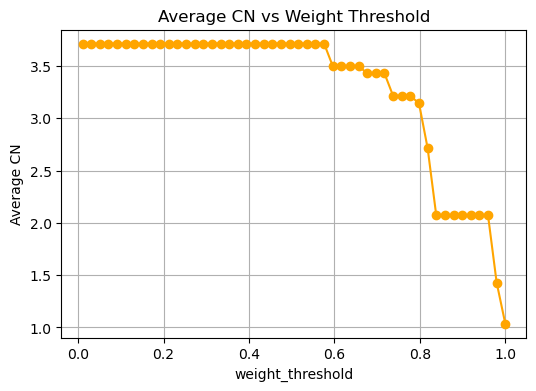

Recommended weight_threshold: 0.576


In [24]:
import matplotlib.pyplot as plt
from collections import defaultdict
recommended_threshold, cn_dict = recommend_voronoi_threshold(structural_motifs_vnn)

# 局部配位环境特征

In [15]:
def calculate_bond_angles(neighbors):
    angles = []
    n_neighbors = len(neighbors)
    if n_neighbors < 2:
        return angles
    vectors = [neighbor['vector'] for neighbor in neighbors]
    for i in range(n_neighbors):
        for j in range(i + 1, n_neighbors):
            vec1 = vectors[i]
            vec2 = vectors[j]
            dot_product = np.dot(vec1, vec2)
            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)
            if norm1 > 0 and norm2 > 0:
                cos_angle = np.clip(dot_product / (norm1 * norm2), -1.0, 1.0)
                angle = np.degrees(np.arccos(cos_angle))
                angles.append(angle)
    return angles

In [16]:
def calculate_shape_descriptors(neighbor_vectors, prefix):
    features = {}
    if len(neighbor_vectors) < 2:
        return features
    vectors = np.array(neighbor_vectors)
    # 惯性张量
    if len(vectors) > 0:
        inertia_tensor = np.zeros((3, 3))
        for vec in vectors:
            r_sq = np.dot(vec, vec)
            inertia_tensor += np.eye(3) * r_sq - np.outer(vec, vec)
        eigenvalues = np.linalg.eigvalsh(inertia_tensor)
        eigenvalues = np.sort(eigenvalues)
        features[f'{prefix}_inertia_min'] = eigenvalues[0]
        features[f'{prefix}_inertia_mid'] = eigenvalues[1]
        features[f'{prefix}_inertia_max'] = eigenvalues[2]
        features[f'{prefix}_inertia_ratio'] = eigenvalues[0] / eigenvalues[2] if eigenvalues[2] > 0 else 0
    # 径向分布
    distances = [np.linalg.norm(vec) for vec in neighbor_vectors]
    if distances:
        features[f'{prefix}_radial_std'] = np.std(distances)
        features[f'{prefix}_radial_asymmetry'] = np.max(distances) / np.min(distances) if np.min(distances) > 0 else 0
    # 角度分布
    if len(neighbor_vectors) >= 3:
        angles = []
        for i in range(len(vectors)):
            for j in range(i + 1, len(vectors)):
                dot_product = np.dot(vectors[i], vectors[j])
                norm_i = np.linalg.norm(vectors[i])
                norm_j = np.linalg.norm(vectors[j])
                if norm_i > 0 and norm_j > 0:
                    cos_angle = np.clip(dot_product / (norm_i * norm_j), -1.0, 1.0)
                    angle = np.degrees(np.arccos(cos_angle))
                    angles.append(angle)
        if angles:
            features[f'{prefix}_angle_diversity'] = np.std(angles)
    return features

def calculate_topological_features(neighbor_vectors, prefix):
    features = {}
    if len(neighbor_vectors) < 3:
        return features
    vectors = np.array(neighbor_vectors)
    try:
        hull = ConvexHull(vectors)
        features[f'{prefix}_convex_volume'] = hull.volume
        features[f'{prefix}_convex_area'] = hull.area
    except:
        features[f'{prefix}_convex_volume'] = 0
        features[f'{prefix}_convex_area'] = 0
    if features.get(f'{prefix}_convex_volume', 0) > 0:
        features[f'{prefix}_sphericity'] = (36 * np.pi * features[f'{prefix}_convex_volume'] ** 2) ** (1 / 3) / \
                                           features[f'{prefix}_convex_area']
    else:
        features[f'{prefix}_sphericity'] = 0
    if len(vectors) >= 3:
        inertia_tensor = np.zeros((3, 3))
        for vec in vectors:
            r_sq = np.dot(vec, vec)
            inertia_tensor += np.eye(3) * r_sq - np.outer(vec, vec)
        eigenvalues = np.linalg.eigvalsh(inertia_tensor)
        eigenvalues = np.sort(eigenvalues)
        if eigenvalues[2] > 0:
            anisotropy = 1 - 3 * eigenvalues[0] / np.sum(eigenvalues)
            features[f'{prefix}_anisotropy'] = anisotropy
    return features

def calculate_symmetry_features(neighbor_vectors, prefix):
    features = {}
    if len(neighbor_vectors) < 2:
        return features
    vectors = np.array(neighbor_vectors)
    distances = [np.linalg.norm(vec) for vec in vectors]
    if distances:
        unique_distances = len(set(np.round(distances, 3)))
        features[f'{prefix}_unique_distances'] = unique_distances
        features[f'{prefix}_distance_symmetry'] = len(distances) / unique_distances if unique_distances > 0 else 0
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            dot_product = np.dot(vectors[i], vectors[j])
            norm_i = np.linalg.norm(vectors[i])
            norm_j = np.linalg.norm(vectors[j])
            if norm_i > 0 and norm_j > 0:
                cos_angle = np.clip(dot_product / (norm_i * norm_j), -1.0, 1.0)
                angle = np.degrees(np.arccos(cos_angle))
                angles.append(angle)
    if angles:
        unique_angles = len(set(np.round(angles, 3)))
        features[f'{prefix}_unique_angles'] = unique_angles
        features[f'{prefix}_angle_symmetry'] = len(angles) / unique_angles if unique_angles > 0 else 0
    return features

In [17]:
from scipy.special import sph_harm
from scipy.spatial import ConvexHull

def radial_features(center, neighbor_coords):
    dists = np.linalg.norm(neighbor_coords - center, axis=1)
    return {
        #"dist_mean": float(np.mean(dists)),
      #  "dist_std": float(np.std(dists)),
       # "dist_min": float(np.min(dists)),
      #  "dist_max": float(np.max(dists)),
        "dist_skew": float(np.mean((dists - np.mean(dists))**3) / (np.std(dists)**3 + 1e-8)),
        "dist_unique": len(np.unique(np.round(dists, 3)))
    }

def angular_features(center, neighbor_coords):
    vecs = neighbor_coords - center
    n = len(vecs)
    if n < 2:
        return {"angle_mean": 0, "angle_std": 0, "angle_min": 0, "angle_max": 0, "angle_entropy": 0}
    norms = np.linalg.norm(vecs, axis=1)
    angles = []
    for i in range(n):
        for j in range(i+1, n):
            cosang = np.dot(vecs[i], vecs[j]) / (norms[i]*norms[j] + 1e-8)
            angles.append(np.degrees(np.arccos(np.clip(cosang, -1, 1))))
    angles = np.array(angles)
    hist, _ = np.histogram(angles, bins=12, range=(0, 180), density=True)
    entropy = -np.sum(hist * np.log(hist + 1e-10))
    return {
        #"angle_mean": float(np.mean(angles)),
        #"angle_std": float(np.std(angles)),
        #"angle_min": float(np.min(angles)),
       # "angle_max": float(np.max(angles)),
        "angle_entropy": float(entropy)
    }

def dihedral_features(center, neighbor_coords):
    vecs = neighbor_coords - center
    n = len(vecs)
    if n < 4:
        return {"dihedral_mean": 0, "dihedral_std": 0, "dihedral_entropy": 0}
    angles = []
    for i in range(n):
        for j in range(i+1, n):
            for k in range(j+1, n):
                for l in range(k+1, n):
                    a, b, c, d = vecs[i], vecs[j], vecs[k], vecs[l]
                    n1 = np.cross(a, b)
                    n2 = np.cross(c, d)
                    if np.linalg.norm(n1) < 1e-6 or np.linalg.norm(n2) < 1e-6:
                        continue
                    cosang = np.dot(n1, n2) / (np.linalg.norm(n1)*np.linalg.norm(n2))
                    angles.append(np.degrees(np.arccos(np.clip(cosang, -1, 1))))
    if len(angles) == 0:
        return {"dihedral_mean": 0, "dihedral_std": 0, "dihedral_entropy": 0}
    angles = np.array(angles)
    hist, _ = np.histogram(angles, bins=10, range=(0, 180), density=True)
    entropy = -np.sum(hist * np.log(hist + 1e-10))
    return {
        "dihedral_mean": float(np.mean(angles)),
        "dihedral_std": float(np.std(angles)),
        "dihedral_entropy": float(entropy)
    }

In [18]:
def steinhardt_QW(center, neighbor_coords, ls=[2,4,6,8]):
    vecs = neighbor_coords - center
    n = len(vecs)
    if n == 0:
        return {f"Q{l}":0 for l in ls} | {f"W{l}":0 for l in ls}
    # 坐标转换 (Cartesian to Spherical)
    # 注意：scipy 的 sph_harm 定义通常是 (m, l, theta, phi) 
    # 其中 theta 是方位角(0-2pi), phi 是极角(0-pi)，需核对你使用的 scipy 版本文档
    # 假设标准物理定义：phi=方位角(x-y平面), theta=极角(z轴夹角)
    rs = np.linalg.norm(vecs, axis=1)
    # 防止除零
    rs[rs == 0] = 1e-10 
    
    # theta: z轴夹角 [0, pi]
    thetas = np.arccos(np.clip(vecs[:, 2] / rs, -1, 1))
    # phi: x-y平面角度 [0, 2pi]
    phis = np.arctan2(vecs[:, 1], vecs[:, 0])

    result = {}
    for l in ls:
        # 1. 计算所有 m 分量 (-l 到 l)
        ms = np.arange(-l, l+1)
        Ylms = sph_harm(ms[:, None], l, phis[None, :], thetas[None, :]) 

        Q_bar_lm = np.mean(Ylms, axis=1) # shape: (2l+1,)


        sum_sq = np.sum(np.abs(Q_bar_lm)**2)
        Q_l = np.sqrt((4 * np.pi / (2 * l + 1)) * sum_sq)
        result[f"Q{l}"] = float(Q_l)
        
        W_l_val = 0.0

        norm_factor = (sum_sq)**1.5 + 1e-10
        
        for i, m1 in enumerate(range(-l, l+1)):
            for j, m2 in enumerate(range(-l, l+1)):
                m3 = -m1 - m2
                if -l <= m3 <= l:
                    k = m3 + l 

                    term = Q_bar_lm[i] * Q_bar_lm[j] * Q_bar_lm[k]

                    W_l_val += np.real(term) 
                    
        result[f"W{l}"] = float(W_l_val / norm_factor)

    return result

In [19]:
def extract_motif_features(structural_motifs):
    motif_features = []
    for motif in structural_motifs:
        features = {}
        neighbors = motif['neighbors']
        neighbor_vectors = [n['vector'] for n in neighbors]
        distances = [n['distance'] for n in neighbors]
        angles = calculate_bond_angles(neighbors)

        # ---- 保留原有特征 ----
        n_neighbors = len(neighbors)
        features['coordination'] = n_neighbors
        if distances:
            features.update({
                'avg_distance': np.mean(distances),
                'distance_std': np.std(distances) if n_neighbors > 1 else 0,
                'min_distance': np.min(distances),
                'max_distance': np.max(distances),
                'distance_range': np.max(distances)-np.min(distances)
            })
        else:
            features.update({k:0 for k in ['avg_distance','distance_std','min_distance','max_distance','distance_range']})

        if angles:
            features.update({
                'avg_angle': np.mean(angles),
                'angle_std': np.std(angles),
                'angle_min': np.min(angles),
                'angle_max': np.max(angles),
                'angle_range': np.max(angles)-np.min(angles)
            })
        else:
            features.update({k:0 for k in ['avg_angle','angle_std','angle_min','angle_max','angle_range']})

        # ---- 原有拓扑、对称性、形状描述符 ----
        features.update(calculate_topological_features(neighbor_vectors, prefix=''))
        features.update(calculate_symmetry_features(neighbor_vectors, prefix=''))
        features.update(calculate_shape_descriptors(neighbor_vectors, prefix=''))

        # ---- 新增局部几何特征 ----
        center = np.zeros(3)  # 假设中心在原点
        neigh_coords = np.array(neighbor_vectors)
        features.update(radial_features(center, neigh_coords))
        features.update(angular_features(center, neigh_coords))
        features.update(dihedral_features(center, neigh_coords))
        features.update(steinhardt_QW(center, neigh_coords))

        motif_features.append(features)
    return motif_features

In [20]:
# Q_l 越接近 1 → 局部环境越规则  W_l 描述多面体的对称性扭曲 接近 0 → 说明基元几乎没有扭曲
# rmsd 表示与理想的偏差（理想是 0）

In [21]:
import pandas as pd
features_list = extract_motif_features(representative_motifs)
df = pd.DataFrame(features_list)
print(df)

   coordination  avg_distance  distance_std  min_distance  max_distance  \
0            12      3.147783  8.208646e-16      3.147783      3.147783   
1             6      2.225819  4.440892e-16      2.225818      2.225819   
2             6      2.840461  4.346181e-01      2.225818      3.147783   

   distance_range   avg_angle  angle_std  angle_min  angle_max  ...  \
0    2.664535e-15   98.181818  36.386356       60.0      180.0  ...   
1    8.881784e-16  108.000000  36.000000       90.0      180.0  ...   
2    9.219642e-01  108.000000  36.000000       90.0      180.0  ...   

   dihedral_std  dihedral_entropy            Q2            W2        Q4  \
0     37.628593          0.222749  1.184784e-16  2.959839e-40  0.190941   
1     42.676712          0.198748  7.590352e-17  5.640121e-40  0.763763   
2     31.493440          0.204816  2.225627e-16  5.373124e-39  0.763763   

         W4        Q6        W6        Q8      W8  
0 -1.400231  0.574524 -0.972272  0.403915  1.5937  
1  1.4002

/tmp/ipykernel_44232/3344355046.py:23: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylms = sph_harm(ms[:, None], l, phis[None, :], thetas[None, :])


In [22]:
df.columns

Index(['coordination', 'avg_distance', 'distance_std', 'min_distance',
       'max_distance', 'distance_range', 'avg_angle', 'angle_std', 'angle_min',
       'angle_max', 'angle_range', '_convex_volume', '_convex_area',
       '_sphericity', '_anisotropy', '_unique_distances', '_distance_symmetry',
       '_unique_angles', '_angle_symmetry', '_inertia_min', '_inertia_mid',
       '_inertia_max', '_inertia_ratio', '_radial_std', '_radial_asymmetry',
       '_angle_diversity', 'dist_skew', 'dist_unique', 'angle_entropy',
       'dihedral_mean', 'dihedral_std', 'dihedral_entropy', 'Q2', 'W2', 'Q4',
       'W4', 'Q6', 'W6', 'Q8', 'W8'],
      dtype='object')

In [23]:
for i, feat in enumerate(features_list):
    print(f"基元 {i}:")
    for k, v in feat.items():
        print(f"  {k}: {v}")
    print("-" * 30)


基元 0:
  coordination: 12
  avg_distance: 3.147782710080939
  distance_std: 8.208645989907719e-16
  min_distance: 3.147782710080937
  max_distance: 3.1477827100809397
  distance_range: 2.6645352591003757e-15
  avg_angle: 98.18181814111821
  angle_std: 36.38635644700863
  angle_min: 59.999999999999986
  angle_max: 180.0
  angle_range: 120.00000000000001
  _convex_volume: 73.5153423806691
  _convex_area: 93.77539146551646
  _sphericity: 0.9049971846504148
  _anisotropy: 3.3306690738754696e-16
  _unique_distances: 1
  _distance_symmetry: 12.0
  _unique_angles: 4
  _angle_symmetry: 16.5
  _inertia_min: 79.26828791907596
  _inertia_mid: 79.26828791907599
  _inertia_max: 79.268287919076
  _inertia_ratio: 0.9999999999999994
  _radial_std: 8.208645989907719e-16
  _radial_asymmetry: 1.0000000000000009
  _angle_diversity: 36.38635644700863
  dist_skew: -6.933508026607167e-38
  dist_unique: 1
  angle_entropy: 0.27301295401400255
  dihedral_mean: 93.48322485584106
  dihedral_std: 37.62859254655424


# 可视化

In [24]:
all_motifs_features = extract_motif_features(structural_motifs)

/tmp/ipykernel_44232/3344355046.py:23: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Ylms = sph_harm(ms[:, None], l, phis[None, :], thetas[None, :])


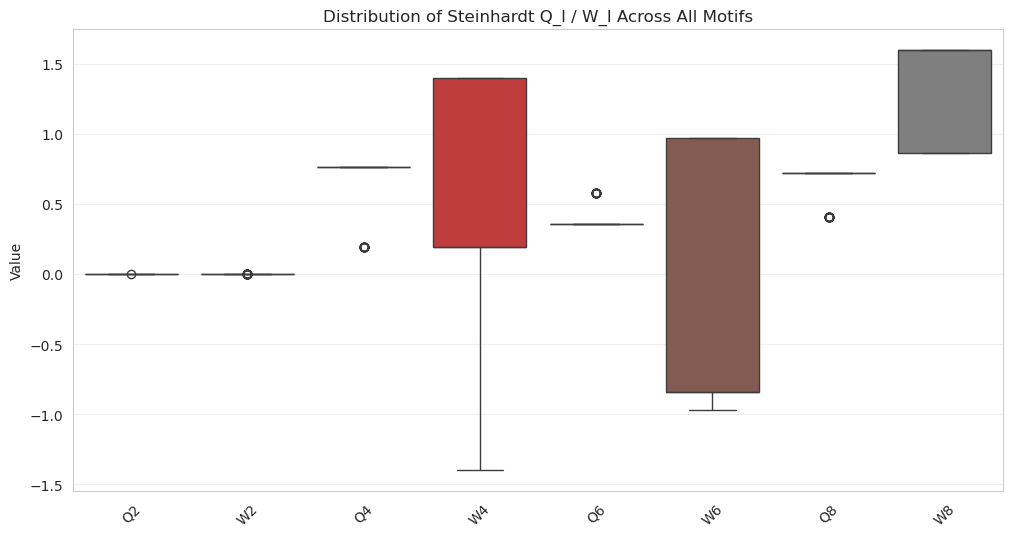

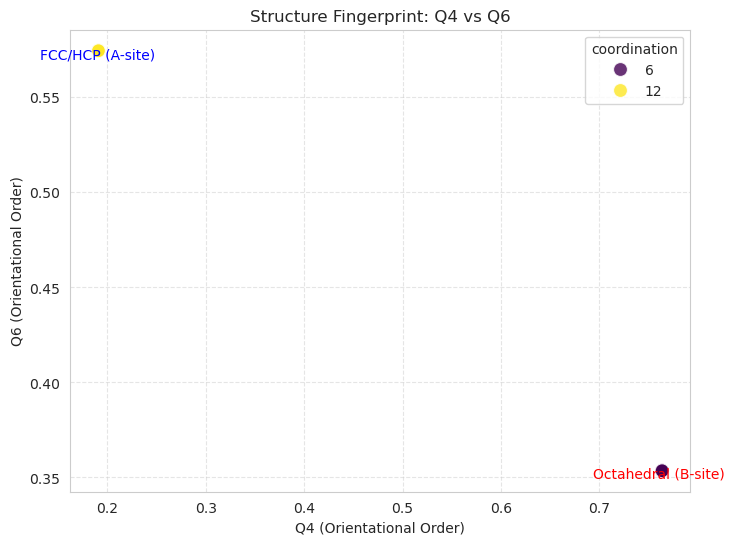

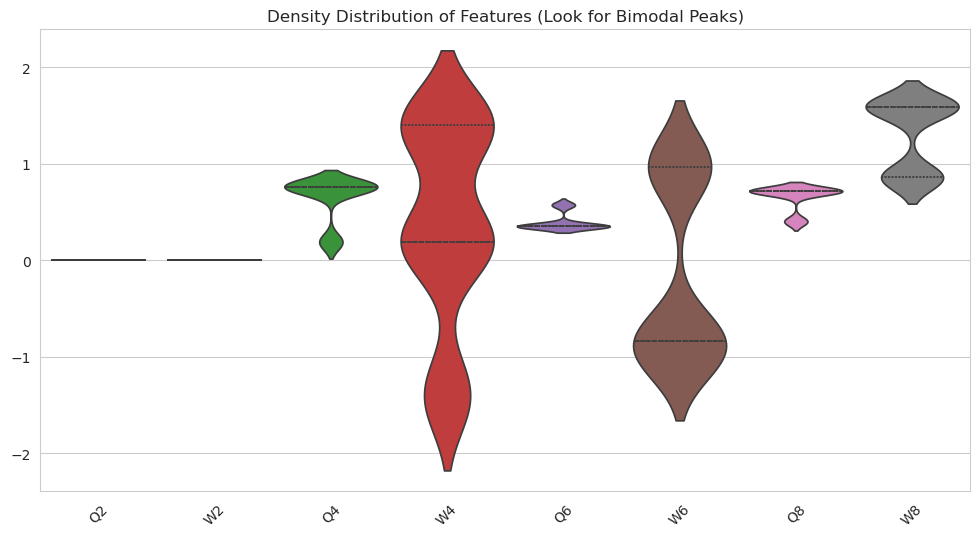

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df_features = pd.DataFrame(all_motifs_features)

qw_columns = [col for col in df_features.columns if col.startswith('Q') or col.startswith('W')]
df_qw = df_features[qw_columns]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_qw)
plt.title("Distribution of Steinhardt Q_l / W_l Across All Motifs")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# --- 图表 2: Q4 vs Q6 散点图 (晶体结构指纹图) ---

if 'Q4' in df_qw.columns and 'Q6' in df_qw.columns:
    plt.figure(figsize=(8, 6))
    # 使用 coordination (如果存在) 作为颜色区分，效果更佳
    if 'coordination' in df_features.columns:
        sns.scatterplot(data=df_features, x='Q4', y='Q6', hue='coordination', palette='viridis', s=100, alpha=0.8)
    else:
        sns.scatterplot(data=df_features, x='Q4', y='Q6', s=100, alpha=0.7)
    
    plt.title("Structure Fingerprint: Q4 vs Q6")
    plt.xlabel("Q4 (Orientational Order)")
    plt.ylabel("Q6 (Orientational Order)")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 标注一些经典结构的理论区域 (参考用)
    plt.text(0.76, 0.35, 'Octahedral (B-site)', color='red', fontsize=10, ha='center')
    plt.text(0.19, 0.57, 'FCC/HCP (A-site)', color='blue', fontsize=10, ha='center')
    plt.show()

# --- 图表 3: 小提琴图 (查看是否存在双峰/多峰分布) ---

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_qw, inner="quartile")
plt.title("Density Distribution of Features (Look for Bimodal Peaks)")
plt.xticks(rotation=45)
plt.show()

# 权重问题--1

In [30]:
from scipy.spatial.distance import pdist, squareform
import numpy as np
X = df.values.astype(float)

dist_matrix = squareform(pdist(X, metric='euclidean'))

print("基元之间的距离矩阵:")
print(dist_matrix)

基元之间的距离矩阵:
[[  0.          41.82581184 161.19271533 162.20147509 125.19235578
  125.45235459 118.72106584 124.10234622]
 [ 41.82581184   0.         168.34329214 169.38334939 127.89295884
  132.04424274 121.14727709 130.48288644]
 [161.19271533 168.34329214   0.           5.2553985   93.46906419
   49.45233421  94.53216495  54.62210039]
 [162.20147509 169.38334939   5.2553985    0.          94.28196681
   51.26064089  95.32081843  57.27368794]
 [125.19235578 127.89295884  93.46906419  94.28196681   0.
   99.08192111   7.52611851 100.38706971]
 [125.45235459 132.04424274  49.45233421  51.26064089  99.08192111
    0.          96.74278371  11.09924965]
 [118.72106584 121.14727709  94.53216495  95.32081843   7.52611851
   96.74278371   0.          98.02357898]
 [124.10234622 130.48288644  54.62210039  57.27368794 100.38706971
   11.09924965  98.02357898   0.        ]]


In [18]:
avg_distances = dist_matrix.mean(axis=1)
for i, d in enumerate(avg_distances):
    print(f"基元 {i} 平均距离: {d:.4f}")


基元 0 平均距离: 85.9366
基元 1 平均距离: 92.6719
基元 2 平均距离: 54.8836
基元 3 平均距离: 56.4122
基元 4 平均距离: 49.1389
基元 5 平均距离: 46.5482
基元 6 平均距离: 46.8698
基元 7 平均距离: 48.2314


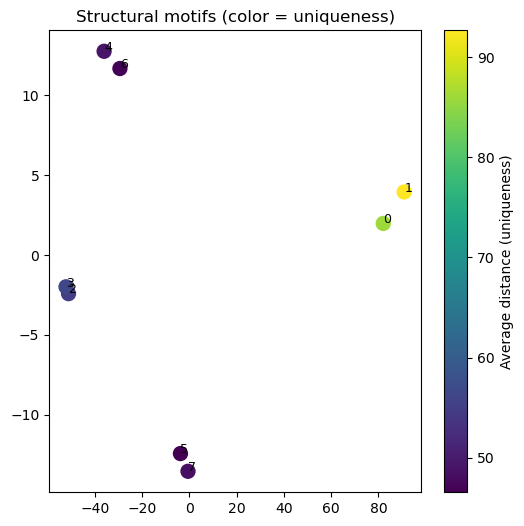

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=100, c=avg_distances, cmap='viridis')
for i, (x, y) in enumerate(X_pca):
    plt.text(x+0.02, y+0.02, f'{i}', fontsize=9)
plt.colorbar(label='Average distance (uniqueness)')
plt.title('Structural motifs (color = uniqueness)')
plt.show()


In [85]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

# X: N x F 的特征矩阵
dist_matrix = squareform(pdist(X, metric='euclidean'))

# 平均距离
avg_distances = dist_matrix.mean(axis=1)

# 权重归一化
weights = avg_distances / np.sum(avg_distances)

print("基元权重:", weights)


基元权重: [nan nan nan nan nan]


In [21]:
type(features_list)

list

# 权重问题2

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import numpy as np

def compute_motif_weights_standardized(features_list, method='hybrid', scale_method='zscore'):
    """
    计算基元加权值（标准化 + 方差/距离加权）
    features_list: list of dicts, 每个 dict 对应一个基元的特征
    method: 'variance', 'distance', 'hybrid'
    scale_method: 'zscore' 或 'minmax'
    """
    # === Step 1: 构建特征矩阵 ===
    all_keys = sorted({k for f in features_list for k in f.keys()})
    X = np.zeros((len(features_list), len(all_keys)))
    for i, f in enumerate(features_list):
        for j, k in enumerate(all_keys):
            v = f.get(k, 0.0)
            # 替换 inf 或 nan 为 nan
            if np.isinf(v) or np.isnan(v):
                v = np.nan
            X[i, j] = v

    # === Step 2: 填充 NaN ===
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

    # === Step 3: 标准化 ===
    if scale_method == 'zscore':
        scaler = StandardScaler()
        
    elif scale_method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("scale_method 必须是 'zscore' 或 'minmax'")
    X_scaled = scaler.fit_transform(X)

    # === Step 4: 计算方差权重 ===
    var_w = np.var(X_scaled, axis=1)  # 每个基元内部特征的方差

    # === Step 5: 计算距离权重（基元与其他基元特征距离） ===
    mean_vec = np.mean(X_scaled, axis=0)
    dist_w = np.linalg.norm(X_scaled - mean_vec, axis=1)

    # === Step 6: 合并权重 ===
    if method == 'variance':
        weights = var_w
    elif method == 'distance':
        weights = dist_w
    elif method == 'hybrid':
        weights = var_w + dist_w
    else:
        raise ValueError("method 必须是 'variance', 'distance' 或 'hybrid'")

    return weights, all_keys, X_scaled, var_w, dist_w


In [27]:
weights, all_keys, X_scaled, var_w, dist_w = compute_motif_weights_standardized(features_list, method='hybrid')

for i, w in enumerate(weights):
    print(f"基元 {i}: 总权重={w:.4f}, 方差贡献={var_w[i]:.4f}, 距离贡献={dist_w[i]:.4f}")


基元 0: 总权重=8.6916, 方差贡献=1.3050, 距离贡献=7.3866
基元 1: 总权重=5.6088, 方差贡献=0.5040, 距离贡献=5.1048
基元 2: 总权重=6.9211, 方差贡献=0.8896, 距离贡献=6.0315


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (5).

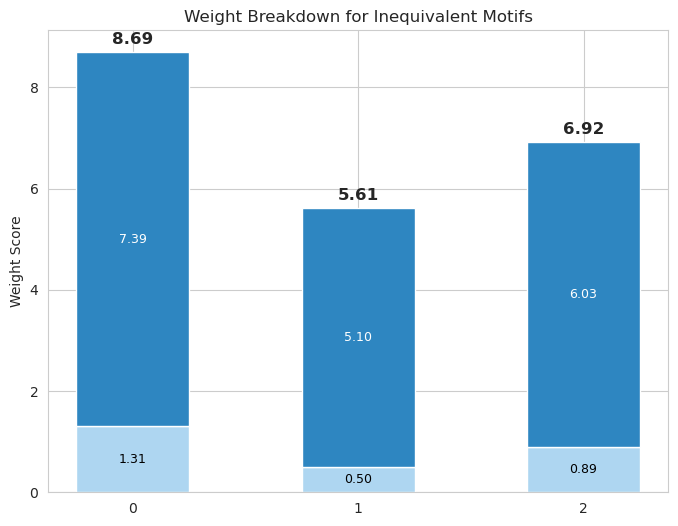

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_motif_contribution(var_w, dist_w, labels=None):
    n = len(var_w)
    if labels is None:
        labels = [f"Motif {i}" for i in range(n)]

    x = np.arange(n)
    width = 0.5

    fig, ax = plt.subplots(figsize=(8, 6))

    p1 = ax.bar(x, var_w, width, label='Variance Contribution', color='#AED6F1', edgecolor='white')
    p2 = ax.bar(x, dist_w, width, bottom=var_w, label='Distance Contribution', color='#2E86C1', edgecolor='white')

    for i in range(n):
        total = var_w[i] + dist_w[i]
        # 显示总权重
        ax.text(i, total + 0.1, f"{total:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=12)
        ax.text(i, var_w[i]/2, f"{var_w[i]:.2f}", ha='center', va='center', color='black', fontsize=9)
        ax.text(i, var_w[i] + dist_w[i]/2, f"{dist_w[i]:.2f}", ha='center', va='center', color='white', fontsize=9)

    ax.set_ylabel('Weight Score')
    ax.set_title('Weight Breakdown for Inequivalent Motifs')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # 添加网格线方便读数
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

motif_labels = ['Motif 0', 'Motif 1', 'Motif 2','Motif 3','Motif 4'] 
plot_motif_contribution(var_w, dist_w, motif_labels)

In [29]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

def plot_variance_with_distorted(var_w, structrual_motifs):
    """
    使用已有的方差贡献 var_w 和 structural_motifs 绘制柱状图，
    扭曲基元用红色，正常基元用蓝色。
    
    Parameters:
    - var_w: np.array，每个基元的方差贡献
    - structural_motifs: list，每个基元字典中包含 'distorted' 字段
    """
    distorted_flags = np.array([m.get('distorted', False) for m in structrual_motifs])
    colors = np.where(distorted_flags, 'salmon', 'skyblue')
    
    plt.figure(figsize=(10,5))
    bars = plt.bar(range(len(var_w)), var_w, color=colors, edgecolor='k')
    
    plt.xlabel("Motif index")
    plt.ylabel("Variance contribution")
    plt.title("Motif Variance Contribution")
    
    # 在柱子上显示具体方差值
    for bar, w in zip(bars, var_w):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{w:.3f}", ha='center', va='bottom', fontsize=9)
    
    # 图例
    red_patch = mpatches.Patch(color='salmon', label='Distorted')
    blue_patch = mpatches.Patch(color='skyblue', label='Normal')
    plt.legend(handles=[red_patch, blue_patch])
    
    plt.tight_layout()
    plt.show()


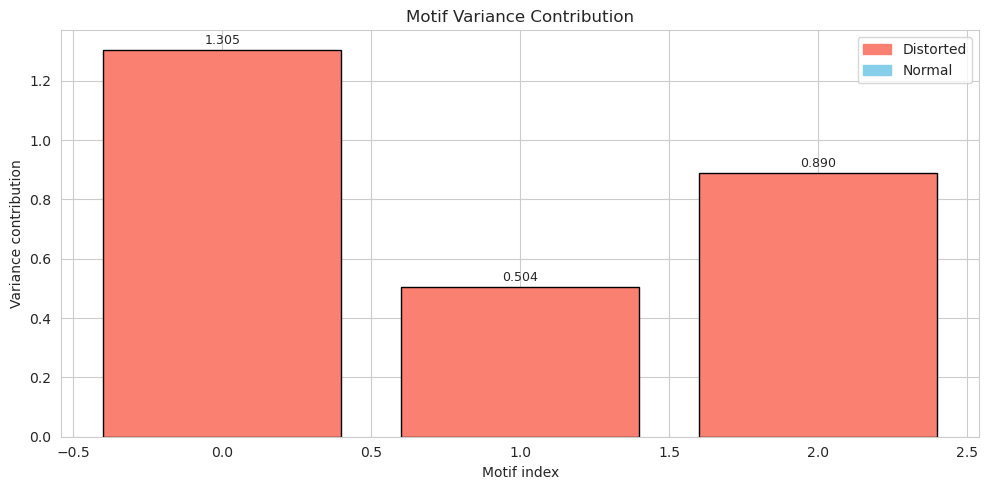

In [30]:
plot_variance_with_distorted(var_w, representative_motifs)

In [31]:
representative_motifs

[{'central_atom': {'species': 'Ba',
   'coords': array([0.16666667, 0.16666667, 0.16666667]),
   'wyckoff': '27b',
   'index': 0,
   'representative_index': 0,
   'group_id': 0},
  'coordination_number': 12,
  'coordination_environment': 'cuboctahedral',
  'distorted': True,
  'rms_angle_deviation': 43.47097490230036,
  'neighbors': [{'species': 'O',
    'coords': array([4.451637 , 2.2258185, 4.451637 ]),
    'weight': 1,
    'distance': 3.147782710080937,
    'vector': array([2.2258185, 0.       , 2.2258185]),
    'index': 118,
    'is_rescued': False},
   {'species': 'O',
    'coords': array([2.2258185, 4.451637 , 4.451637 ]),
    'weight': 1,
    'distance': 3.1477827100809375,
    'vector': array([4.4408921e-16, 2.2258185e+00, 2.2258185e+00]),
    'index': 85,
    'is_rescued': False},
   {'species': 'O',
    'coords': array([2.2258185, 0.       , 4.451637 ]),
    'weight': 1,
    'distance': 3.147782710080938,
    'vector': array([-8.8817842e-16, -2.2258185e+00,  2.2258185e+00]),


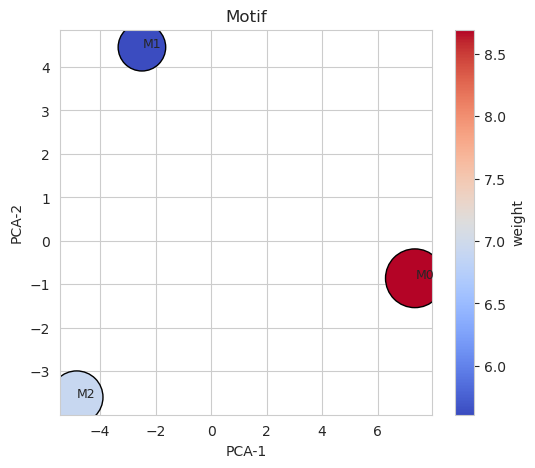

In [32]:
from sklearn.decomposition import PCA
all_keys = sorted(set().union(*[f.keys() for f in features_list]))
X = np.array([[feat.get(k, 0.0) for k in all_keys] for feat in features_list], dtype=float)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=weights, s=200*weights + 50, cmap='coolwarm', edgecolor='k')
plt.colorbar(sc, label="weight")
for i in range(len(X_2d)):
    plt.text(X_2d[i,0]+0.02, X_2d[i,1], f'M{i}', fontsize=9)
plt.title("Motif")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.show()

In [33]:
def weighted_features(features_list, weights):
    """
    根据每个基元的权重，计算整个样本的加权局部特征。
    
    Parameters:
    - features_list: list of dict，每个基元的局部特征
    - weights: array-like, 每个基元的权重 (长度与features_list一致)
    
    Returns:
    - aggregated_features: dict, 样本级加权特征
    """
    if len(features_list) != len(weights):
        raise ValueError("features_list 和 weights 长度必须一致")
    
    weights = np.array(weights, dtype=float)
    weights = weights / np.sum(weights)  # 归一化

    all_keys = sorted(set().union(*[f.keys() for f in features_list]))
    aggregated_features = {}

    for key in all_keys:
        # 收集每个基元的特征值
        values = np.array([feat.get(key, 0.0) for feat in features_list], dtype=float)
        # 加权平均
        weighted_mean = np.sum(values * weights)
        aggregated_features[f'{key}_mean'] = weighted_mean
        # 加权方差（可选，反映样本内部特征差异）
        weighted_var = np.sum(weights * (values - weighted_mean)**2)
        aggregated_features[f'{key}_var'] = weighted_var

    return aggregated_features


In [34]:
local_features = weighted_features(features_list, weights)

# 查看结果
for k, v in local_features.items():
    print(f"{k}: {v:.4f}")

Q2_mean: 0.0000
Q2_var: 0.0000
Q4_mean: 0.5292
Q4_var: 0.0793
Q6_mean: 0.4441
Q6_var: 0.0118
Q8_mean: 0.5894
Q8_var: 0.0239
W2_mean: 0.0000
W2_var: 0.0000
W4_mean: 0.2533
W4_var: 1.8965
W6_mean: 0.1759
W6_var: 0.9144
W8_mean: 1.5937
W8_var: 0.0000
_angle_diversity_mean: 36.1582
_angle_diversity_var: 0.0361
_angle_symmetry_mean: 11.1861
_angle_symmetry_var: 19.5876
_anisotropy_mean: 0.0326
_anisotropy_var: 0.0022
_convex_area_mean: 65.7593
_convex_area_var: 613.3784
_convex_volume_mean: 43.5857
_convex_volume_var: 652.9352
_distance_symmetry_mean: 7.4790
_distance_symmetry_var: 15.4922
_inertia_max_mean: 50.6293
_inertia_max_var: 626.2742
_inertia_mid_mean: 47.3978
_inertia_mid_var: 718.9130
_inertia_min_mean: 47.3978
_inertia_min_var: 718.9130
_inertia_ratio_mean: 0.9185
_inertia_ratio_var: 0.0137
_radial_asymmetry_mean: 1.1351
_radial_asymmetry_var: 0.0377
_radial_std_mean: 0.1417
_radial_std_var: 0.0415
_sphericity_mean: 0.8622
_sphericity_var: 0.0014
_unique_angles_mean: 2.8191
_uni

In [35]:
print(type(local_features))

<class 'dict'>


验证是否扭曲

In [88]:
# 取第一个基元
motif = structural_motifs[0]
neighbors = motif['neighbors']
central = motif['central_atom']

# 配位数
CN = len(neighbors)
print(f"Central atom: {central['species']} ({central['wyckoff']})")
print(f"Coordination number (CN): {CN}")

# 计算所有键长
distances = [n['distance'] for n in neighbors]
if distances:
    avg_dist = np.mean(distances)
    min_dist = np.min(distances)
    max_dist = np.max(distances)
    std_dist = np.std(distances)
    print(f"Bond lengths (Å): {distances}")
    print(f"Average: {avg_dist:.3f}, Min: {min_dist:.3f}, Max: {max_dist:.3f}, Std: {std_dist:.3f}")

# 计算所有角度
angles = calculate_bond_angles(neighbors)
print(f"Bond angles (degrees): {angles}")

# 平均角度和标准差
if angles:
    avg_angle = np.mean(angles)
    std_angle = np.std(angles)
    print(f"Average angle: {avg_angle:.2f}, Std: {std_angle:.2f}")


Central atom: Sr2+ (16a)
Coordination number (CN): 12
Bond lengths (Å): [2.995116477332954, 2.995116477332954, 2.995116477332954, 2.995116477332954, 2.9951164773329544, 2.995116477332954, 2.995116477332955, 2.995116477332954, 2.995116477332955, 2.9951164773329553, 2.9951164773329553, 2.9951164773329553]
Average: 2.995, Min: 2.995, Max: 2.995, Std: 0.000
Bond angles (degrees): [70.76913539355358, 67.0530595300451, 67.0530595300451, 173.41693681607592, 118.91423985739809, 56.65578732600099, 117.13226727949292, 118.9142398573981, 56.65578732600097, 109.63145036206923, 117.13226727949292, 56.65578732600096, 118.91423985739813, 109.63145036206924, 117.13226727949295, 67.0530595300451, 56.65578732600096, 67.0530595300451, 117.13226727949295, 173.4169368160758, 118.91423985739809, 67.05305953004513, 118.91423985739809, 70.7691353935536, 109.63145036206926, 56.65578732600096, 117.13226727949295, 118.9142398573981, 117.13226727949295, 173.4169368160758, 117.1322672794929, 56.65578732600096, 117

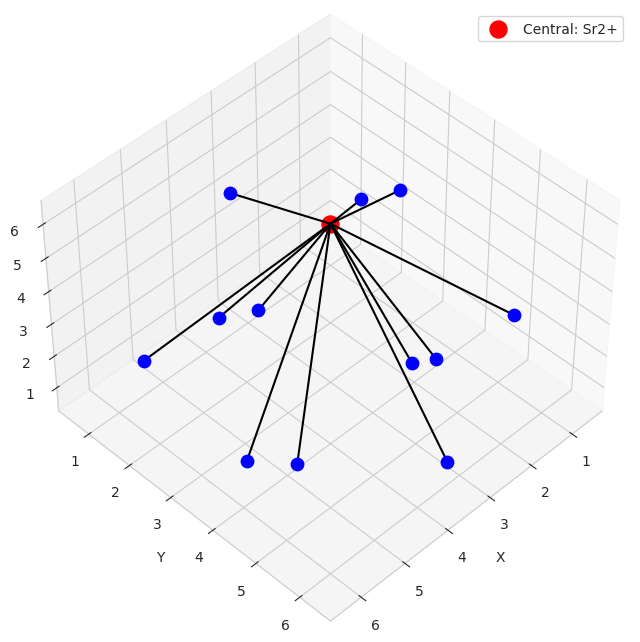

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# 中心原子和邻居
central_coords = motif['central_atom']['coords']
neighbors = motif['neighbors']

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# 绘制中心原子
ax.scatter(*central_coords, c='red', s=150, label=f"Central: {motif['central_atom']['species']}")

# 绘制邻居原子
for n in neighbors:
    ax.scatter(*n['coords'], c='blue', s=80)

# 连接中心和邻居，显示真实键长
for n in neighbors:
    neighbor_coords = n['coords']
    line = np.array([central_coords, neighbor_coords])
    ax.plot(line[:,0], line[:,1], line[:,2], 'k-', lw=1.5)

# 设置坐标轴比例一致，保证空间真实
max_range = np.array([central_coords] + [n['coords'] for n in neighbors]).ptp(axis=0).max() / 2.0
mid_x = (np.array([central_coords[0]] + [n['coords'][0] for n in neighbors]).max() + 
         np.array([central_coords[0]] + [n['coords'][0] for n in neighbors]).min()) * 0.5
mid_y = (np.array([central_coords[1]] + [n['coords'][1] for n in neighbors]).max() + 
         np.array([central_coords[1]] + [n['coords'][1] for n in neighbors]).min()) * 0.5
mid_z = (np.array([central_coords[2]] + [n['coords'][2] for n in neighbors]).max() + 
         np.array([central_coords[2]] + [n['coords'][2] for n in neighbors]).min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.legend()

# 可旋转视角，观察不同角度
ax.view_init(elev=45, azim=45)

plt.show()


基元之间关系特征

In [36]:
def is_cation(species_str, structure, site_index):
    """
    基于氧化态判断是否为阳离子。
    """
    try:
        # 尝试获取该位点的氧化态
        oxi = structure[site_index].specie.oxi_state
        return oxi > 0
    except (AttributeError, ValueError, IndexError):
        # 兜底：查表法
        typical_cations = {
            'Li', 'Na', 'K', 'Rb', 'Cs', 'Mg', 'Ca', 'Sr', 'Ba', 
            'Sc', 'Y', 'Ti', 'Zr', 'Hf', 'V', 'Nb', 'Ta', 'Cr', 'Mo', 'W', 
            'Mn', 'Tc', 'Re', 'Fe', 'Ru', 'Os', 'Co', 'Rh', 'Ir', 
            'Ni', 'Pd', 'Pt', 'Cu', 'Ag', 'Au', 'Zn', 'Cd', 'Hg', 
            'Al', 'Ga', 'In', 'Tl', 'Si', 'Ge', 'Sn', 'Pb', 'Sb', 'Bi',
            'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu'
        }
        # 去掉氧化态数字，只留元素符号
        element = "".join([c for c in species_str if c.isalpha()])
        return element in typical_cations

In [37]:
def identify_anions_general(motifs, structure):
    """
    动态识别体系中的阴离子类型
    """
    anion_species = set()
    for motif in motifs:
        # 检查中心原子是否是阴离子
        idx = motif['central_atom']['index']
        try:
            if structure[idx].specie.oxi_state < 0:
                anion_species.add(motif['central_atom']['species'])
        except:
            pass
        
        # 检查邻居
        for n in motif['neighbors']:
            # 注意：邻居列表里可能没有氧化态信息，需要回查结构
            # 但为了速度，这里可以用查表法兜底，或者假设邻居主要是阴离子
            species_str = n['species']
            element = "".join([c for c in species_str if c.isalpha()])
            if element in {'O', 'F', 'Cl', 'Br', 'I', 'S', 'Se', 'Te', 'N', 'P'}:
                anion_species.add(species_str)
    return sorted(list(anion_species))

In [38]:
def count_shared_anions(motif_i, motif_j, anion_species, tolerance_ratio=None):
    """
   基于真实坐标距离匹配 (Coordinate Matching)
    解决小晶胞索引碰撞 (Small Cell Artifact) 问题
    """
    # 提取阴离子邻居的【绝对坐标】
    # 注意：这里我们假设 structural_motifs 里的 n['coords'] 是绝对坐标
    coords_i = [n['coords'] for n in motif_i['neighbors'] if n['species'] in anion_species]
    coords_j = [n['coords'] for n in motif_j['neighbors'] if n['species'] in anion_species]
    
    shared_count = 0
    spatial_tolerance = 0.1 # 0.1 Å 的物理重合容差

    for c_i in coords_i:
        for c_j in coords_j:
            # 计算欧几里得距离
            dist = np.linalg.norm(c_i - c_j)
            if dist < spatial_tolerance:
                shared_count += 1
                break # 找到了匹配，跳出内层循环，继续找下一个 i
                
    return shared_count, [], []

In [39]:
from collections import defaultdict
def analyze_type_based_connectivity(G, motif_types):
    """分析基于基元类型的连接模式"""
    features = {}
    
    # 统计不同类型基元之间的连接
    type_connections = defaultdict(int)
    for i, j in G.edges():
        type_i = motif_types[i]
        type_j = motif_types[j]
        connection_key = f"{type_i}_{type_j}" if type_i <= type_j else f"{type_j}_{type_i}"
        type_connections[connection_key] += 1
    # 添加最重要的连接类型
    sorted_connections = sorted(type_connections.items(), key=lambda x: x[1], reverse=True)
    for idx, (conn_type, count) in enumerate(sorted_connections[:10]):  # 前5种连接类型
        features[f'motif_connection_{conn_type}'] = count
    
    return features

In [40]:
def calculate_cation_anion_ratio(structural_motifs, structure, anion_species):
    """
    计算阳离子-阴离子比例
    """
    cation_count = 0
    anion_count = 0

    for motif in structural_motifs:
        central_species = motif['central_atom']['species']
        idx = motif['central_atom']['index']
        
        if is_cation(central_species, structure, idx):
            cation_count += 1
        elif central_species in anion_species:
            anion_count += 1

    return cation_count / anion_count if anion_count > 0 else 0

# 测试

In [41]:
def extract_graph_features(adj_matrix, prefix):
    # 如果传入的是 numpy 矩阵
    if isinstance(adj_matrix, np.ndarray):
        G = nx.from_numpy_array(adj_matrix)
    else:
        G = adj_matrix # 已经是 nx Graph

    isolates = list(nx.isolates(G))
    G.remove_nodes_from(isolates)
    n_nodes = G.number_of_nodes()

    if n_nodes > 0:
        # 基本拓扑
        n_components = nx.number_connected_components(G)
        density = nx.density(G)
        avg_clustering = nx.average_clustering(G)
        
        degrees = [d for n, d in G.degree()]
        avg_degree = np.mean(degrees)
        
        # 路径与直径 (耗时操作，只对最大连通子图做)
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        if subgraph.number_of_edges() > 0:
            diameter = nx.diameter(subgraph)
            # avg_path = nx.average_shortest_path_length(subgraph) # 太慢可注释
            avg_path = 0 
        else:
            diameter = 0
            avg_path = 0
    else:
        return {
            f'{prefix}_nodes': 0, f'{prefix}_edges': 0, f'{prefix}_components': 0,
            f'{prefix}_density': 0, f'{prefix}_avg_degree': 0, f'{prefix}_diameter': 0,
            f'{prefix}_avg_clustering': 0
        }

    return {
        f'{prefix}_nodes': n_nodes,
        f'{prefix}_edges': G.number_of_edges(),
        f'{prefix}_density': density,
        f'{prefix}_components': n_components,
        f'{prefix}_diameter': diameter,
        f'{prefix}_avg_degree': avg_degree,
        f'{prefix}_avg_clustering': avg_clustering
    }

# 测试结束

In [86]:
# ============================================================================
# 1. 通用图特征提取 
# ============================================================================
def extract_graph_features(adj_matrix, prefix):

    G = nx.from_numpy_array(adj_matrix)

    isolates = list(nx.isolates(G))
    G.remove_nodes_from(isolates)
    
    n_nodes = G.number_of_nodes()
    
    if n_nodes > 0:
        # 连通分量 (最重要的指标)
        n_components = nx.number_connected_components(G)
        density = nx.density(G)
        
        # 度统计
        degrees = [d for n, d in G.degree()]
        avg_degree = np.mean(degrees)
        max_degree = np.max(degrees)
        degree_std = np.std(degrees)
        
        # 聚类系数
        avg_clustering = nx.average_clustering(G)
        n_edges = G.number_of_edges()
        
        # 路径与直径 (仅在最大子图中计算)
        if n_edges > 0:
            largest_cc = max(nx.connected_components(G), key=len)
            subgraph = G.subgraph(largest_cc)
            diameter = nx.diameter(subgraph)
            avg_path = nx.average_shortest_path_length(subgraph)
        else:
            diameter = 0; avg_path = 0
    else:
        # 空图兜底
        return {
            f'{prefix}_nodes': 0, f'{prefix}_edges': 0,
            f'{prefix}_components': 0, f'{prefix}_avg_degree': 0
        }

    return {
        f'{prefix}_nodes': n_nodes,
        f'{prefix}_edges': G.number_of_edges(),
        f'{prefix}_density': density,
        f'{prefix}_components': n_components,
        f'{prefix}_diameter': diameter,
        f'{prefix}_avg_path_length': avg_path,
        f'{prefix}_avg_degree': avg_degree,
        f'{prefix}_max_degree': max_degree,
        f'{prefix}_degree_std': degree_std,
        f'{prefix}_avg_clustering': avg_clustering
    }

# RDF版本

In [42]:
import numpy as np
from scipy.signal import find_peaks

def detect_optimal_cutoff(structure, bin_size=0.1, plot=False):
    """
    基于 RDF 峰谷法自动确定阳离子截断半径 (RDF Valley Method)
    修正版：适配 3 参数的 is_cation 函数
    """
    # 1. 提取所有感兴趣的原子（仅阳离子）
    # 修正点：使用 enumerate 获取索引 i，并传入 structure 和 i
    cation_sites = []
    for i, s in enumerate(structure):
        # 获取元素符号（保留原始带价态的字符串也没关系，is_cation 内部会处理或清洗）
        symbol = s.specie.symbol 
        
        # 调用你的 3 参数函数
        if is_cation(symbol, structure, i):
            cation_sites.append(s)
    
    # 或者用列表推导式写法（更简洁）：
    # cation_sites = [s for i, s in enumerate(structure) if is_cation(s.specie.symbol, structure, i)]

    if len(cation_sites) < 2:
        return 3.5  # 原子太少，返回保底值

    # 修正点：必须使用分数坐标 (Frac Coords) 计算 PBC 距离
    frac_coords = [s.frac_coords for s in cation_sites]
    
    # 2. 计算所有成对距离 (PBC corrected)
    # get_all_distances 返回的是笛卡尔距离 (Angstrom)，但输入需要分数坐标
    dists = structure.lattice.get_all_distances(frac_coords, frac_coords)
    
    # 展平并去掉 0 (自己到自己)
    dists = dists.flatten()
    dists = dists[dists > 0.1] # 去掉极小值
    
    # 3. 统计直方图 (RDF)
    # 硫化物间距大，上限设为 8.0 是合理的
    bins = np.arange(0, 8.0 + bin_size, bin_size)
    hist, bin_edges = np.histogram(dists, bins=bins)
    
    # 4. 寻找峰值
    # distance=5 表示峰之间至少间隔 0.5 Å (5 * 0.1)，防止噪点
    # prominence 设为 max 的 10%，保证只找主峰
    peaks, properties = find_peaks(hist, distance=5, prominence=np.max(hist)*0.1)
    
    cutoff = 3.5 # 默认保底值

    if len(peaks) > 0:
        first_peak_idx = peaks[0]
        
        # 寻找谷底 (Valley)
        if len(peaks) > 1:
            second_peak_idx = peaks[1]
            # 在第一峰和第二峰之间找最小值
            search_range = hist[first_peak_idx : second_peak_idx]
            # 加上 first_peak_idx 偏移量
            valley_relative_idx = np.argmin(search_range)
            valley_idx = first_peak_idx + valley_relative_idx
        else:
            # 只有一个峰 (比较少见，可能是晶胞很小或 cutoff 上限太低)
            # 策略：取峰后下降到峰值 10% 处，或者往后延 1.5 Å
            # 这里简单处理：往后找 15 个 bin (1.5 Å) 范围内的最小值
            search_end = min(len(hist), first_peak_idx + 15)
            search_range = hist[first_peak_idx : search_end]
            valley_idx = first_peak_idx + np.argmin(search_range)
        
        # 获取对应的距离值
        cutoff = bin_edges[valley_idx]
        
        # 🛡️ 安全检查：如果算出 2.0 这种不合理的值，强制修正
        if cutoff < 2.5:
            cutoff = bin_edges[first_peak_idx] + 0.8

    # (可选) 画图调试
    if plot:
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(8, 4))
            plt.bar(bin_edges[:-1], hist, width=bin_size, alpha=0.6, color='gray')
            plt.plot(bin_edges[:-1], hist, color='black')
            plt.plot(bin_edges[peaks], hist[peaks], "x", color='red', label="Peaks")
            plt.axvline(x=cutoff, color='blue', linestyle='--', linewidth=2, label=f"Cutoff={cutoff:.2f}")
            plt.title(f"Cation-Cation RDF (Cutoff = {cutoff:.2f} A)")
            plt.legend()
            plt.show()
        except: pass

    return round(float(cutoff), 2)

# RDF加强版本 
##如果两个峰值之间的间距小于1埃的话就瞄准到第二个峰值

In [43]:
import numpy as np
from scipy.signal import find_peaks

def detect_optimal_cutoff(structure, bin_size=0.1, plot=False):
    """
    RDF 截断半径自动判定 - 策略 B (保守合并模式)
    
    核心逻辑：
    如果检测到前两个峰距离很近 (< 1.0 Å)，认为它们属于同一个配位层的分裂（Splitting），
    强制在第二个峰之后寻找谷底截断，防止切断晶格骨架。
    """
    
    # =========================================================================
    # 1. 提取阳离子并计算距离 (Standard RDF Prep)
    # =========================================================================
    cation_sites = []
    # 假设你外部已经有了 is_cation 判断，这里简化演示
    for i, s in enumerate(structure):
        if s.specie.symbol not in ['O', 'F', 'Cl', 'S']: # 简单排除常见阴离子
             cation_sites.append(s)

    if len(cation_sites) < 2:
        return 4.0 # 无法计算时的保守值

    frac_coords = [s.frac_coords for s in cation_sites]
    dists = structure.lattice.get_all_distances(frac_coords, frac_coords)
    dists = dists.flatten()
    # 过滤掉 0 距离和太近的距离(小于 2.0 Å 通常不是阳离子间距)
    dists = dists[dists > 2.0] 
    
    # =========================================================================
    # 2. 生成直方图 (Histogram)
    # =========================================================================
    bins = np.arange(0, 10.0 + bin_size, bin_size)
    hist, bin_edges = np.histogram(dists, bins=bins)
    
    # =========================================================================
    # 3. 寻找峰值 (Find Peaks)
    # =========================================================================
    # 适当降低 prominence 以识别分裂的小峰
    peaks, _ = find_peaks(hist, distance=3, prominence=np.max(hist)*0.03)
    
    cutoff = 4.5 # 默认保底值

    if len(peaks) > 0:
        # 获取峰的位置 (Å)
        peak_positions = bin_edges[peaks]
        
        # --- 策略 B 核心逻辑 ---
        target_peak_idx = peaks[0] # 默认瞄准第一个峰
        strategy_triggered = False

        if len(peaks) >= 2:
            first_peak_pos = peak_positions[0]
            second_peak_pos = peak_positions[1]
            peak_dist = second_peak_pos - first_peak_pos
            
            # 【判定条件】: 如果前两个峰距离小于 1.0 Å
            if peak_dist < 1.0:
                print(f"检测到峰分裂 (Δ={peak_dist:.2f} Å < 1.0 Å)。")
                print(f"   -> 将忽略第一个峰 ({first_peak_pos:.2f} Å)，瞄准第二个峰 ({second_peak_pos:.2f} Å)。")
                target_peak_idx = peaks[1] # 瞄准第二个峰
                strategy_triggered = True
            else:
                # 如果距离够远，检查谁是最高峰 (Max Peak Safety)
                # 如果第二个峰比第一个峰高很多，可能第一个只是杂质，还是取最高峰稳妥
                if hist[peaks[1]] > hist[peaks[0]] * 1.5:
                     target_peak_idx = peaks[1]

        # --- 寻找截断谷底 (Valley Finding) ---
        # 我们需要在 target_peak_idx 之后寻找最小值
        
        # 找到 target_peak_idx 在 peaks 列表中的位置
        current_ptr = np.where(peaks == target_peak_idx)[0][0]
        
        # 确定搜索范围：从当前峰 到 下一个峰 之间
        if current_ptr < len(peaks) - 1:
            next_peak_idx = peaks[current_ptr + 1]
            search_range = hist[target_peak_idx : next_peak_idx]
            
            if len(search_range) > 0:
                valley_relative = np.argmin(search_range)
                valley_idx = target_peak_idx + valley_relative
                cutoff = bin_edges[valley_idx]
                
                # 修正：如果谷底离峰太近 (< 0.5 Å)，说明谷底不明显，强制往后推
                if cutoff - bin_edges[target_peak_idx] < 0.5:
                    cutoff = bin_edges[target_peak_idx] + 0.8
            else:
                cutoff = bin_edges[target_peak_idx] + 1.0
        else:
            # 如果后面没有峰了，直接加一个经验值 (覆盖配位层)
            cutoff = bin_edges[target_peak_idx] + 1.2

        # =====================================================================
        # 4. 硬性安全检查 (Safety Net)
        # =====================================================================
        # 双钙钛矿阳离子间距极少小于 3.2 Å。如果 cutoff 过小，肯定是切错了。
        if cutoff < 3.2:
            print(f"警告: 计算出的 Cutoff ({cutoff:.2f} Å) 过小，触发硬性修正。")
            cutoff = 4.5

    # (可选) 画图调试
    if plot:
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(7, 3.5))
            plt.bar(bin_edges[:-1], hist, width=bin_size, alpha=0.5, color='gray', label='RDF')
            plt.plot(bin_edges[peaks], hist[peaks], "x", color='red')
            
            # 标记我们选中的那个“目标峰”
            if len(peaks) > 0:
                plt.plot(bin_edges[target_peak_idx], hist[target_peak_idx], "o", color='green', label="Target Peak")

            plt.axvline(x=cutoff, color='blue', linestyle='--', linewidth=2, label=f"Cutoff={cutoff:.2f}")
            plt.title(f"Strategy B: Merge Split Peaks (Cutoff = {cutoff:.2f} Å)")
            plt.legend()
            plt.show()
        except: pass

    return round(float(cutoff), 2)

# 尖晶石版本

In [81]:
import numpy as np
from collections import defaultdict


def analyze_motif_connectivity(structural_motifs, structure,
                               distance_cutoff=None, tolerance_ratio=0.15,
                               cutoff_min=2.0, cutoff_max=8.0, step=0.1):
    """
    结构基元连接关系分析（最终修正版）
    核心改进：
    1. 加入 Species Filter，只计算同种阳离子（如 Al-Al）的连接，剔除 A-B 干扰。
    2. 采用双图解耦（骨架图 + 金属图）。
    """
    # 1. 自动检测截断距离
    if distance_cutoff is None:
       # best_cutoff, _, _ = detect_optimal_cutoff(structural_motifs, structure,
                                                  #cutoff_min=cutoff_min, cutoff_max=cutoff_max, step=step)
       # distance_cutoff = best_cutoff if best_cutoff else 3.5
       distance_cutoff = detect_optimal_cutoff(structure, bin_size=0.1,plot=True)
    print(f"🔹 阳离子–阳离子截断半径: {distance_cutoff:.2f} Å")

    # 2. 阴离子识别
    anion_species = identify_anions_general(structural_motifs, structure)
    
    print(f"识别到的阴离子类型: {anion_species}")
    
    # 3. 初始化矩阵
    n_motifs = len(structural_motifs)
    adj_poly = np.zeros((n_motifs, n_motifs))   # 多面体连接 (权重=共用阴离子数)
    adj_cation = np.zeros((n_motifs, n_motifs)) # 阳离子网络 (权重=1)

    all_matched_anions = set()
    cat_anion_ratio = calculate_cation_anion_ratio(structural_motifs, structure, anion_species)

    # 4. 遍历基元对
    for i in range(n_motifs):
        motif_i = structural_motifs[i]
        species_i = motif_i['central_atom']['species']
        
        for j in range(i + 1, n_motifs):
            motif_j = structural_motifs[j]
            species_j = motif_j['central_atom']['species']

            # =================================================================
            #  核心修正：只计算同种阳离子的连接 (Focus on Homo-Cation Framework)
            # =================================================================
            # 物理原因：在尖晶石中，我们只关心 B-B 骨架 (Al-Al) 的连接性。
            # A-B (Al-Zn) 之间虽然共享阴离子，但属于异质连接，
            # 在拓扑上容易因 PBC 造成“共面”假象，必须剔除。
            if species_i != species_j:
                continue
            # =================================================================

            # --- 通道 A: 多面体连接 (Polyhedral Connectivity) ---
            # 使用基于 index 的严格匹配，无需担心 tolerance
            shared_count, _, matched_ids = count_shared_anions(
                motif_i, motif_j, anion_species, tolerance_ratio
            )
            
            if shared_count > 0:
                adj_poly[i, j] = shared_count  # 权重 = 共用阴离子数 (1, 2, 3)
                adj_poly[j, i] = shared_count
                all_matched_anions.update(matched_ids)

            # --- 通道 B: 阳离子直连 (Cation Network) ---
            center_i = motif_i['central_atom']['coords']
            center_j = motif_j['central_atom']['coords']
            distance = structure.lattice.get_distance_and_image(center_i, center_j)[0]
            
            if distance is None or np.isnan(distance): continue

            # 判定是否均为阳离子 (且同种，上面已过滤)
            is_cation_i = is_cation(species_i, structure, motif_i['central_atom']['index'])
            is_cation_j = is_cation(species_j, structure, motif_j['central_atom']['index'])

            if is_cation_i and is_cation_j and distance < distance_cutoff:
                adj_cation[i, j] = 1.0 
                adj_cation[j, i] = 1.0

    # 5. 提取特征
    poly_features = extract_graph_features(adj_poly, prefix="poly")
    cat_features = extract_graph_features(adj_cation, prefix="cat")

    # 6. 合并特征
    final_features = {**poly_features, **cat_features}
    
    # 补充全局特征
    final_features['global_total_anion_bridged'] = len(all_matched_anions)
    final_features['global_cation_anion_ratio'] = cat_anion_ratio
    
    # 计算连接类型比例 (Corner/Edge/Face sharing)
    # shared_count: 1=Corner, 2=Edge, 3+=Face
    total_links = np.sum(adj_poly > 0) / 2
    if total_links > 0:
        face_links = np.sum(adj_poly >= 3) / 2
        edge_links = np.sum(adj_poly == 2) / 2
        corner_links = np.sum(adj_poly == 1) / 2
        
        final_features['poly_frac_face_sharing'] = face_links / total_links
        final_features['poly_frac_edge_sharing'] = edge_links / total_links
        final_features['poly_frac_corner_sharing'] = corner_links / total_links
    else:
        final_features['poly_frac_face_sharing'] = 0
        final_features['poly_frac_edge_sharing'] = 0
        final_features['poly_frac_corner_sharing'] = 0

    return final_features

# 钙钛矿版本

In [ ]:
def auto_detect_a_site_species(structural_motifs, cn_threshold=8.0):
    """
    自动侦测并返回高配位数的 A 位阳离子列表。
    逻辑：在钙钛矿/双钙钛矿中，A 位离子的配位数 (CN) 通常 >= 10 (理想是12)，
          而 B 位骨架通常是 6。
    """
    # 1. 统计每种元素的配位数列表
    species_cn_map = defaultdict(list)
    
    for motif in structural_motifs:
        # 获取纯净的元素符号 (去掉电荷)
        sp_str = str(motif['central_atom']['species'])
        clean_sp = "".join([c for c in sp_str if c.isalpha()])
        
        # 记录该原子的配位数
        cn = motif['coordination_number']
        species_cn_map[clean_sp].append(cn)
        
    # 2. 计算平均配位数并判断
    ignore_list = []
    print("-" * 30)
    print("[Auto-Detect] 正在侦测 A 位阳离子...")
    
    for sp, cn_list in species_cn_map.items():
        avg_cn = np.mean(cn_list)
        print(f"   -> 元素 {sp}: 平均 CN = {avg_cn:.2f}")
        
        # 核心判据：如果平均配位数显著大于阈值 (默认8)，认为是 A 位
        # 典型的 A 位是 12，B 位是 6。
        if avg_cn > cn_threshold:
            ignore_list.append(sp)
            print(f"判定为 A 位 (CN > {cn_threshold}) -> 加入忽略列表")
        else:
            print(f"判定为骨架 B 位/其他 -> 保留")
            
    print(f"自动生成的忽略列表: {ignore_list}")
    print("-" * 30)
    
    return ignore_list

In [92]:
import numpy as np
from scipy.signal import find_peaks

def analyze_motif_connectivity(structural_motifs, structure,
                               distance_cutoff=None, 
                               ignore_species=None,    
                               cation_only=True):     
    
    # --- A. 配置参数 ---
    if ignore_species is None: ignore_species = []
    if distance_cutoff is None: distance_cutoff = 6.0 # 稍微放宽一点默认值
    
    print("="*40)
    print(" 开始通用结构连接性分析")
    print(f"截断半径: {distance_cutoff:.2f} Å")
    print(f"忽略列表 (A位/杂质): {ignore_species}")
    print(f"仅分析阳离子模式: {cation_only}")

    # --- B. 识别阴离子 (用于多面体桥连判断) ---
    anion_list = identify_anions_general(structural_motifs, structure)
    print(f"识别到的桥连阴离子: {anion_list}")

    # --- C. 构建“白名单” (Active Nodes) ---
    # 我们只对白名单里的原子建立连接，其他的全部忽略
    n_motifs = len(structural_motifs)
    valid_indices = []
    
    for i in range(n_motifs):
        motif = structural_motifs[i]
        idx_struct = motif['central_atom']['index']
        sp_str = str(motif['central_atom']['species'])
        clean_sp = "".join([c for c in sp_str if c.isalpha()]) # 去掉电荷

        # 1. 过滤用户指定的 (A位等)
        if clean_sp in ignore_species:
            continue
            
        # 2. 过滤阴离子 (如果开启 cation_only)
        if cation_only:
            # 如果它是刚才识别出的阴离子，或者是公认的阴离子，踢掉
            if clean_sp in anion_list or clean_sp in ['O', 'F', 'Cl', 'Br', 'I']:
                continue
                
        valid_indices.append(i)

    print(f"🔹 有效骨架节点数: {len(valid_indices)} / {n_motifs} (已过滤 A位/阴离子)")

    # --- D. 建立矩阵 (只针对有效节点连线) ---
    adj_poly = np.zeros((n_motifs, n_motifs))
    adj_cation = np.zeros((n_motifs, n_motifs))
    matched_bridges = set()

    # 双重循环只跑 valid_indices，大幅提高效率
    for k in range(len(valid_indices)):
        i = valid_indices[k]
        motif_i = structural_motifs[i]
        
        for m in range(k + 1, len(valid_indices)):
            j = valid_indices[m]
            motif_j = structural_motifs[j]
            
            # --- 连接逻辑 1: 共用阴离子 (Polyhedral) ---
            ids_i = {n['index'] for n in motif_i['neighbors'] 
                     if "".join([c for c in str(n['species']) if c.isalpha()]) in anion_list}
            ids_j = {n['index'] for n in motif_j['neighbors'] 
                     if "".join([c for c in str(n['species']) if c.isalpha()]) in anion_list}
            
            shared = ids_i.intersection(ids_j)
            if shared:
                count = len(shared)
                adj_poly[i, j] = count
                adj_poly[j, i] = count
                matched_bridges.update(shared)

            # --- 连接逻辑 2: 直接距离 (Cation-Cation) ---
            dist = structure.lattice.get_distance_and_image(
                motif_i['central_atom']['coords'], 
                motif_j['central_atom']['coords']
            )[0]
            
            if dist < distance_cutoff:
                adj_cation[i, j] = 1.0
                adj_cation[j, i] = 1.0

    # --- E. 提取特征 ---
    print("🔹 正在提取图特征 (自动清洗孤立节点)...")
    
    # 这里的关键是：adj矩阵里，被过滤掉的原子行和列全是0
    # extract_graph_features 里的 remove_isolates 会把它们自动踢出统计
    poly_feats = extract_graph_features(adj_poly, "poly")
    cat_feats = extract_graph_features(adj_cation, "cat")
    
    final = {**poly_feats, **cat_feats}
    final['global_total_anion_bridged'] = len(matched_bridges)
    
    # 计算连接类型比例
    n_links = np.sum(adj_poly > 0) / 2
    if n_links > 0:
        final['poly_frac_corner_sharing'] = (np.sum(adj_poly == 1)/2) / n_links
        final['poly_frac_edge_sharing'] = (np.sum(adj_poly == 2)/2) / n_links
        final['poly_frac_face_sharing'] = (np.sum(adj_poly >= 3)/2) / n_links
    else:
        final['poly_frac_corner_sharing'] = 0.0
        final['poly_frac_edge_sharing'] = 0.0
        final['poly_frac_face_sharing'] = 0.0

    print("✅ 分析完成")
    return final

In [56]:
def run_complete_analysis(structural_motifs, structure, distance_cutoff=None):
    print("开始结构基元连接关系分析...")
    print("=" * 50)
    auto_ignore_list = auto_detect_a_site_species(structural_motifs, cn_threshold=8.0)
    connectivity_features = analyze_motif_connectivity(
        structural_motifs,
        structure,
        ignore_species=auto_ignore_list,
        cation_only=True,
        distance_cutoff=distance_cutoff
    )

    print("\n连接分析主要特征:")
    for k, v in connectivity_features.items():
        if k not in ['connection_details', 'adjacency_matrix']:
            print(f"{k}: {v}")

    return connectivity_features


In [57]:
# 调试：查看前几个邻居的 species 到底长什么样
if len(structural_motifs) > 0 and len(structural_motifs[0]['neighbors']) > 0:
    print("Debug Species Name:", repr(structural_motifs[0]['neighbors'][0]['species']))
    print("Type:", type(structural_motifs[0]['neighbors'][0]['species']))
else:
    print("警告：基元没有邻居数据！")

Debug Species Name: 'O'
Type: <class 'str'>


In [58]:
import networkx as nx
# 运行完整的连接分析
connectivity_features = run_complete_analysis(structural_motifs, structure)

开始结构基元连接关系分析...
------------------------------
[Auto-Detect] 正在侦测 A 位阳离子...
   -> 元素 Ba: 平均 CN = 12.00
判定为 A 位 (CN > 8.0) -> 加入忽略列表
   -> 元素 Tb: 平均 CN = 6.00
判定为骨架 B 位/其他 -> 保留
   -> 元素 O: 平均 CN = 6.00
判定为骨架 B 位/其他 -> 保留
自动生成的忽略列表: ['Ba']
------------------------------
检测到峰分裂 (Δ=0.60 Å < 1.0 Å)。
   -> 将忽略第一个峰 (3.80 Å)，瞄准第二个峰 (4.40 Å)。
[Auto] 检测到的最佳阳离子互连 Cutoff: 5.20 Å
🔹 有效骨架节点数: 27
正在提取几何与拓扑特征...

连接分析主要特征:
poly_mean_dist: 4.451637
poly_std_dist: 9.204863097018305e-16
poly_mean_angle: 180.0
poly_std_angle: 0.0
poly_nodes: 27
poly_edges: 81
poly_density: 0.23076923076923078
poly_components: 1
poly_diameter: 3
poly_avg_degree: 6.0
poly_avg_clustering: 0.20000000000000007
cat_mean_dist: 4.451637
cat_std_dist: 9.204863097018305e-16
cat_mean_angle: 180.0
cat_std_angle: 0.0
cat_nodes: 27
cat_edges: 81
cat_density: 0.23076923076923078
cat_components: 1
cat_diameter: 3
cat_avg_degree: 6.0
cat_avg_clustering: 0.20000000000000007
poly_frac_corner_sharing: 1.0
poly_frac_edge_sharing: 0.0
poly_fra

In [54]:
# 获取用于机器学习的特征
connectivity_features = {k: v for k, v in connectivity_features.items() 
                           if not isinstance(v, (dict, list, np.ndarray))}
print(type(connectivity_features))
for key, value in connectivity_features.items():
    print(f"{key}: {value}")

<class 'dict'>
poly_mean_dist: 4.451637
poly_std_dist: 9.204863097018305e-16
poly_mean_angle: 120.0
poly_std_angle: 84.8528137423857
poly_nodes: 27
poly_edges: 81
poly_density: 0.23076923076923078
poly_components: 1
poly_diameter: 3
poly_avg_degree: 6.0
poly_avg_clustering: 0.20000000000000007
cat_mean_dist: 4.451637
cat_std_dist: 9.204863097018305e-16
cat_mean_angle: 180.0
cat_std_angle: 0.0
cat_nodes: 27
cat_edges: 81
cat_density: 0.23076923076923078
cat_components: 1
cat_diameter: 3
cat_avg_degree: 6.0
cat_avg_clustering: 0.20000000000000007
poly_frac_corner_sharing: 1.0
poly_frac_edge_sharing: 0.0
poly_frac_face_sharing: 0.0


基元空间排列特征

In [59]:
from scipy.stats import entropy, skew, kurtosis
def safe_entropy(values):
    hist, _ = np.histogram(values, bins='auto', density=True)
    hist = hist + 1e-12
    return entropy(hist)

def enhanced_shape_features(points):
    """全局空间增强特征：PCA、Convex Hull、NN统计、角度熵、偏心率"""
    pts = np.array(points)
    N = len(pts)
    feat = {}

    if N < 1:
        return feat

    centroid = np.mean(pts, axis=0)
    radial = np.linalg.norm(pts - centroid, axis=1)

    feat["radial_mean"] = np.mean(radial)
    feat["radial_std"]  = np.std(radial)
    feat["radial_cv"]   = feat["radial_std"]/(feat["radial_mean"]+1e-12)

    # PCA 各向异性
    if N >= 3:
        cov = np.cov(pts.T)
        vals, vecs = np.linalg.eig(cov)
        vals_sorted = np.sort(vals)[::-1]
        total = np.sum(vals_sorted)+1e-12

        feat["pca_axis_ratio"] = vals_sorted[0]/(vals_sorted[-1]+1e-12)
        feat["pca_1d_ratio"] = vals_sorted[0]/total
        feat["pca_2d_ratio"] = (vals_sorted[0]+vals_sorted[1])/total
        feat["pca_3d_ratio"] = total/total
    else:
        feat["pca_axis_ratio"] = np.nan
        feat["pca_1d_ratio"] = np.nan
        feat["pca_2d_ratio"] = np.nan
        feat["pca_3d_ratio"] = np.nan

    # Convex Hull
    if N >= 4:
        try:
            hull = ConvexHull(pts)
            feat["hull_volume"] = hull.volume
            feat["hull_area"] = hull.area
            feat["hull_density"] = N/(hull.volume+1e-12)
        except:
            feat["hull_volume"] = np.nan
            feat["hull_area"] = np.nan
            feat["hull_density"] = np.nan
    else:
        feat["hull_volume"] = np.nan
        feat["hull_area"] = np.nan
        feat["hull_density"] = np.nan

    # 最近邻统计 + 熵/偏度/峰度
    if N >= 3:
        kd = KDTree(pts)
        nn_d, _ = kd.query(pts, k=2)
        nn = nn_d[:,1]
        feat["nn_mean"] = np.mean(nn)
        feat["nn_std"]  = np.std(nn)
        feat["nn_cv"]   = feat["nn_std"]/(feat["nn_mean"]+1e-12)
        feat["nn_entropy"] = safe_entropy(nn)
        feat["nn_skew"]  = skew(nn)
        feat["nn_kurtosis"] = kurtosis(nn)
    else:
        feat["nn_mean"] = np.nan
        feat["nn_std"] = np.nan
        feat["nn_cv"] = np.nan
        feat["nn_entropy"] = np.nan
        feat["nn_skew"] = np.nan
        feat["nn_kurtosis"] = np.nan

    # 角度熵（方向均匀性）
    if N >= 3:
        vecs = pts - centroid
        angles = []
        for i in range(N):
            for j in range(i+1, N):
                v1, v2 = vecs[i], vecs[j]
                a = np.dot(v1, v2)
                b = np.linalg.norm(v1)*np.linalg.norm(v2)+1e-12
                angles.append(np.arccos(np.clip(a/b, -1, 1)))
        angles = np.array(angles)
        if len(angles) > 0:
            feat["angle_mean"] = np.mean(angles)
            feat["angle_std"]  = np.std(angles)
            feat["angle_entropy"] = safe_entropy(angles)
    else:
        feat["angle_mean"] = np.nan
        feat["angle_std"] = np.nan
        feat["angle_entropy"] = np.nan

    # 偏心率（检测链状/通道状结构）
    if N >= 3:
        max_r = np.max(radial)
        min_r = np.min(radial) if np.min(radial) > 1e-6 else np.nan
        feat["eccentricity"] = max_r/(min_r+1e-12)
    else:
        feat["eccentricity"] = np.nan

    return feat



In [60]:
def group_motifs_by_equivalence(structural_motifs):
    """
    按等价原子组对基元进行分组
    """
    eq_groups = defaultdict(list)
    for idx, motif in enumerate(structural_motifs):
        # 优先尝试获取 wyckoff 标记，如果没有则用 species
        group = motif.get('central_atom', {}).get('equivalent_group_index', None)
        if group is None:
            # 兜底策略：使用元素类型作为分组依据
            group = motif['central_atom']['species']
        eq_groups[group].append(idx)
    return eq_groups

In [61]:
from scipy.spatial import distance, KDTree

def calculate_pairwise_distances(centers):
    """计算所有点对之间的欧几里得距离"""
    n = len(centers)
    distances = []
    for i in range(n):
        for j in range(i+1, n):
            dist = np.linalg.norm(np.array(centers[i]) - np.array(centers[j]))
            distances.append(dist)
    return distances

def calculate_centroid(points):
    """计算点集的质心"""
    return np.mean(points, axis=0)


In [62]:
def compute_weighted_features_population(feature_list, counts):
    """
    [修改] 基于种群数量(Population)的加权//
    原先基于方差的加权在几何特征中物理意义不明确。
    """
    if not feature_list:
        return {}

    all_keys = list(feature_list[0].keys())
    # 提取特征矩阵
    X = np.array([[f.get(k, 0.0) for k in all_keys] for f in feature_list])
    
    # 归一化权重 (根据每组的原子数量)
    total_count = sum(counts)
    if total_count == 0: return {}
    weights = np.array(counts) / total_count

    weighted_features = {}
    for i, k in enumerate(all_keys):
        # 加权均值
        weighted_features[f'{k}_mean'] = np.sum(X[:, i] * weights)
        # 加权最大值 (反映最极端的几何特征，如最小间距)
        weighted_features[f'{k}_min'] = np.min(X[:, i])
        weighted_features[f'{k}_max'] = np.max(X[:, i])
        
    return weighted_features

In [63]:
def analyze_intragroup_arrangement(structural_motifs, structure):
    """
    [核心修改] 分析同一等价组内空间排布 (PBC 修正版)
    """
    eq_groups = group_motifs_by_equivalence(structural_motifs)
    feature_list = []
    group_counts = []

    for group_name, indices in eq_groups.items():
        if len(indices) < 2: continue # 单原子无法计算排布特征

        # 1. 获取分数坐标 (Fractional Coords) 用于 PBC 计算
        frac_coords = [structural_motifs[i]['central_atom']['coords'] for i in indices]
        
        # 2. [关键修复] 使用 pymatgen 内置函数计算考虑 PBC 的距离矩阵
        # get_all_distances 返回一个矩阵，dists[i,j] 是第 i 和 j 个原子的距离
        all_dists_matrix = structure.lattice.get_all_distances(frac_coords, frac_coords)
        
        # 3. 提取上三角矩阵（排除对角线0和重复值）
        n = len(frac_coords)
        # np.triu_indices(n, k=1) 提取上三角，k=1 表示不含对角线
        upper_tri_indices = np.triu_indices(n, k=1)
        pairwise_dists = all_dists_matrix[upper_tri_indices]

        feat = {}
        if len(pairwise_dists) > 0:
            # 基础距离统计
            feat['space_avg_distance'] = np.mean(pairwise_dists)
            feat['space_min_distance'] = np.min(pairwise_dists)
            feat['space_max_distance'] = np.max(pairwise_dists)
            feat['space_distance_std'] = np.std(pairwise_dists)
            
            # 模拟径向分布 (用距离分布代替质心距离，物理上等价且平移不变)
            # 你的 space_radial_std 原意是看原子分布的离散度，这里用成对距离的变异系数代替
            feat['space_radial_std'] = np.std(pairwise_dists) 
            feat['space_radial_asymmetry'] = np.max(pairwise_dists) / (np.min(pairwise_dists) + 1e-8)
        else:
            continue

        # 最近邻统计 (Nearest Neighbor in Sublattice)
        # 在距离矩阵中，对每一行排序，取第二个值（第一个是0，即自己）
        if n > 1:
            # sort axis=1 对每一行排序
            sorted_dists = np.sort(all_dists_matrix, axis=1)
            nn_dists = sorted_dists[:, 1] # 取最近邻
            feat['space_nn_avg'] = np.mean(nn_dists)
            feat['space_nn_std'] = np.std(nn_dists)

        feature_list.append(feat)
        group_counts.append(len(indices)) # 记录原子数量作为权重

    # 使用基于数量的加权合并
    weighted_features = compute_weighted_features_population(feature_list, group_counts)
    return weighted_features

In [64]:
def analyze_intergroup_arrangement(structural_motifs, structure):
    """
    [核心修改] 分析不同等价组间空间排布 (PBC 修正版)
    """
    eq_groups = group_motifs_by_equivalence(structural_motifs)
    group_names = list(eq_groups.keys())
    feature_list = []
    # 组对的权重可以都设为1，或者基于两组原子数的乘积
    pair_weights = [] 

    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            indices_i = eq_groups[group_names[i]]
            indices_j = eq_groups[group_names[j]]
            
            coords_i = [structural_motifs[k]['central_atom']['coords'] for k in indices_i]
            coords_j = [structural_motifs[k]['central_atom']['coords'] for k in indices_j]

            # [关键修复] 计算两组原子间的距离矩阵 (PBC Corrected)
            # 矩阵形状: [len(coords_i), len(coords_j)]
            dists_matrix = structure.lattice.get_all_distances(coords_i, coords_j)
            
            if dists_matrix.size == 0: continue

            feat = {}
            # 展平矩阵以计算整体统计量
            flat_dists = dists_matrix.flatten()
            
            # 两个子晶格之间的“相互”最小距离 (Minimum Separation)
            feat['space_inter_min_distance'] = np.min(flat_dists)
            feat['space_inter_avg_distance'] = np.mean(flat_dists)
            
            # 类似方向幅度的概念，这里用平均距离代替
            feat['space_inter_direction_magnitude'] = np.mean(flat_dists)

            # 组间最近邻 (对于组i中的每个原子，找组j中最近的)
            # axis=1 表示对每一行(i中的原子)找最小值
            min_dists_from_i_to_j = np.min(dists_matrix, axis=1)
            feat['space_inter_nn_avg'] = np.mean(min_dists_from_i_to_j)
            feat['space_inter_nn_std'] = np.std(min_dists_from_i_to_j)

            feature_list.append(feat)
            pair_weights.append(1.0) # 简单平均

    # 加权合并
    weighted_features = compute_weighted_features_population(feature_list, pair_weights)
    return weighted_features

In [65]:
def comprehensive_weighted_spatial_analysis(structural_motifs, structure, representative_motifs=None, weight_method='hybrid'):

    print("开始空间排布特征提取 (PBC修正版)...")
    
    # 1. 同组特征 (传入完整的 structural_motifs 以计算统计量)
    intra_features = analyze_intragroup_arrangement(structural_motifs, structure)
    # print("✅ 同一等价组空间排布特征:", list(intra_features.keys()))

    # 2. 多组特征
    inter_features = analyze_intergroup_arrangement(structural_motifs, structure)
    # print("✅ 不同等价组间空间排布特征:", list(inter_features.keys()))

    # 3. 全局密度特征
    global_features = {
        'global_density': structure.density,
        'global_volume_per_atom': structure.volume / len(structure)
    }

    # 合并所有特征
    all_features = {}
    all_features.update(intra_features)
    all_features.update(inter_features)
    all_features.update(global_features)

    return all_features

In [66]:
weighted_spatial_features = comprehensive_weighted_spatial_analysis(structural_motifs,structure, weight_method='hybrid')

# 类型检查
print(type(weighted_spatial_features))  # <class 'dict'>

# 如果用于机器学习，去掉非标量类型
ml_features = {k: v for k, v in weighted_spatial_features.items() 
               if not isinstance(v, (list, dict, np.ndarray))}

# 输出特征
print("\n用于机器学习的特征:")
for k, v in ml_features.items():
    print(f"{k}: {v:.4f}")

开始空间排布特征提取 (PBC修正版)...
<class 'dict'>

用于机器学习的特征:
space_avg_distance_mean: 2.1571
space_avg_distance_min: 2.1018
space_avg_distance_max: 2.1940
space_min_distance_mean: 1.2231
space_min_distance_min: 1.0493
space_min_distance_max: 1.4839
space_max_distance_mean: 3.1161
space_max_distance_min: 2.5702
space_max_distance_max: 3.4800
space_distance_std_mean: 0.5317
space_distance_std_min: 0.3945
space_distance_std_max: 0.6231
space_radial_std_mean: 0.5317
space_radial_std_min: 0.3945
space_radial_std_max: 0.6231
space_radial_asymmetry_mean: 2.6828
space_radial_asymmetry_min: 1.7321
space_radial_asymmetry_max: 3.3166
space_nn_avg_mean: 1.2231
space_nn_avg_min: 1.0493
space_nn_avg_max: 1.4839
space_nn_std_mean: 0.0000
space_nn_std_min: 0.0000
space_nn_std_max: 0.0000
space_inter_min_distance_mean: 1.0254
space_inter_min_distance_min: 0.7419
space_inter_min_distance_max: 1.2851
space_inter_avg_distance_mean: 2.2374
space_inter_avg_distance_min: 2.1380
space_inter_avg_distance_max: 2.3359
spac

#  版本2

In [ ]:
def compute_weighted_features_population(feature_list, counts):
    """
    [修改] 基于种群数量(Population)的加权//
    原先基于方差的加权在几何特征中物理意义不明确。
    """
    if not feature_list:
        return {}

    all_keys = list(feature_list[0].keys())
    # 提取特征矩阵
    X = np.array([[f.get(k, 0.0) for k in all_keys] for f in feature_list])
    
    # 归一化权重 (根据每组的原子数量)
    total_count = sum(counts)
    if total_count == 0: return {}
    weights = np.array(counts) / total_count

    weighted_features = {}
    for i, k in enumerate(all_keys):
        # 加权均值
        weighted_features[f'{k}_mean'] = np.sum(X[:, i] * weights)
        # 加权最大值 (反映最极端的几何特征，如最小间距)
        weighted_features[f'{k}_min'] = np.min(X[:, i])
        weighted_features[f'{k}_max'] = np.max(X[:, i])
        
    return weighted_features

In [75]:
from scipy.stats import skew, kurtosis
from collections import defaultdict


def calculate_moments(values, prefix):
    """
    通用函数：将一堆距离/角度数据转换为 4 个可解释的统计特征
    """
    if len(values) < 1:
        return {f'{prefix}_mean': 0, f'{prefix}_std': 0, f'{prefix}_skew': 0, f'{prefix}_kurt': 0}
    
    return {
        f'{prefix}_mean': np.mean(values),      # 尺度 (Scale)
        f'{prefix}_std': np.std(values),        # 畸变 (Distortion)
        f'{prefix}_skew': skew(values),         # 偏向 (Asymmetry)
        f'{prefix}_kurt': kurtosis(values)      # 集中度 (Peakedness)
    }

def group_motifs_by_equivalence(structural_motifs):
    """按等价组分组 (Wyckoff > Species)"""
    eq_groups = defaultdict(list)
    for idx, motif in enumerate(structural_motifs):
        # 优先用 Wyckoff，其次用元素
        group = motif.get('central_atom', {}).get('wyckoff', None)
        if group is None:
            group = motif['central_atom']['species']
        eq_groups[group].append(idx)
    return eq_groups

# ==========================================
# 第一层：基元内部排布 (Intra-Motif)
# ==========================================
def analyze_layer1_intra_motif(structural_motifs):
    """
    计算单个基元内部原子的空间排布。
    关注点：键长分布 (Bond Lengths)
    物理意义：描述局部化学环境的“硬度”和“扭曲”。
    """
    eq_groups = group_motifs_by_equivalence(structural_motifs)
    features = []
    weights = []

    for group_name, indices in eq_groups.items():
        # 收集该等价组内【所有】基元的【所有】邻居距离
        # 例如：如果是 B 位，收集所有 B-X 键长
        all_bond_lengths = []
        
        for i in indices:
            neighbors = structural_motifs[i]['neighbors']
            dists = [n['distance'] for n in neighbors]
            all_bond_lengths.extend(dists)
            
        if not all_bond_lengths: continue

        # 计算统计矩 (Mean=平均键长, Std=键长畸变)
        # prefix 命名为 'L1_bond' (Layer 1)
        feats = calculate_moments(all_bond_lengths, 'L1_bond')
        
        # 额外补充：配位数的统计 (防止有些基元配位数不一致)
        cns = [len(structural_motifs[i]['neighbors']) for i in indices]
        feats['L1_cn_mean'] = np.mean(cns)
        
        features.append(feats)
        weights.append(len(indices)) # 权重为该组原子数量

    return compute_weighted_features_population(features, weights)

# ==========================================
# 第二层：同组基元分布 (Intra-Group / Sublattice)
# ==========================================
def analyze_layer2_intra_group(structural_motifs, structure):
    """
    计算处于同一等价组的基元分布。
    关注点：最近邻基元间距 (Nearest Neighbor Distance within Sublattice)
    物理意义：描述子晶格的致密度和晶格畸变。
    """
    eq_groups = group_motifs_by_equivalence(structural_motifs)
    features = []
    weights = []

    for group_name, indices in eq_groups.items():
        if len(indices) < 2: continue
        
        frac_coords = [structural_motifs[i]['central_atom']['coords'] for i in indices]
        
        # 1. 计算子晶格内部的全距离矩阵
        dists_matrix = structure.lattice.get_all_distances(frac_coords, frac_coords)
        np.fill_diagonal(dists_matrix, np.inf) # 排除自己
        
        # 2. 只取【最近邻】
        # 这代表了子晶格中原子排列的紧密程度
        nn_dists = np.min(dists_matrix, axis=1)
        
        # 3. 计算统计矩
        # prefix 命名为 'L2_lattice' (Layer 2)
        feats = calculate_moments(nn_dists, 'L2_lattice')
        
        features.append(feats)
        weights.append(len(indices))

    return compute_weighted_features_population(features, weights)

# ==========================================
# 第三层：异组原子排布 (Inter-Group / Interaction)
# ==========================================
def analyze_layer3_inter_group(structural_motifs, structure):
    """
    计算不同等价组的原子的排布。
    关注点：不同子晶格之间的最近接触距离。
    物理意义：描述位阻效应、容忍因子、层间距。
    """
    eq_groups = group_motifs_by_equivalence(structural_motifs)
    group_names = list(eq_groups.keys())
    features = []
    weights = []

    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            indices_i = eq_groups[group_names[i]]
            indices_j = eq_groups[group_names[j]]

            coords_i = [structural_motifs[k]['central_atom']['coords'] for k in indices_i]
            coords_j = [structural_motifs[k]['central_atom']['coords'] for k in indices_j]

            # 计算两组之间的距离矩阵
            dists_matrix = structure.lattice.get_all_distances(coords_i, coords_j)
            if dists_matrix.size == 0: continue
            
            # 视角 A: 组 i 的每个原子，离组 j 最近的有多远？
            min_i_to_j = np.min(dists_matrix, axis=1)
            # 视角 B: 组 j 的每个原子，离组 i 最近的有多远？
            min_j_to_i = np.min(dists_matrix, axis=0)
            
            combined_nn = np.concatenate([min_i_to_j, min_j_to_i])
            
            # prefix 命名为 'L3_inter' (Layer 3)
            feats = calculate_moments(combined_nn, 'L3_inter')
            
            # 额外特征：绝对最小距离 (Steric Limit)
            feats['L3_global_min_dist'] = np.min(dists_matrix)
            
            features.append(feats)
            weights.append(1.0) 

    return compute_weighted_features_population(features, weights)


def compute_three_layer_spatial_features(structural_motifs, structure):
    
    pass 
    
    print("--- 计算第一层：基元内部 (Bonding) ---")
    f1 = analyze_layer1_intra_motif(structural_motifs)
    
    print("--- 计算第二层：同组分布 (Sublattice) ---")
    f2 = analyze_layer2_intra_group(structural_motifs, structure)
    
    print("--- 计算第三层：异组排布 (Interaction) ---")
    f3 = analyze_layer3_inter_group(structural_motifs, structure)
    
    # 合并所有特征
    final = {**f1, **f2, **f3}
    return final

# 复用之前的加权函数
def compute_weighted_features_population(feature_list, counts):
    if not feature_list: return {}
    all_keys = sorted(list(set().union(*(d.keys() for d in feature_list))))
    total_count = sum(counts)
    if total_count == 0: return {}
    weights = np.array(counts) / total_count
    
    weighted_features = {}
    X = np.zeros((len(feature_list), len(all_keys)))
    for i, f in enumerate(feature_list):
        for j, k in enumerate(all_keys):
            X[i, j] = f.get(k, np.nan)

    for j, k in enumerate(all_keys):
        col = X[:, j]
        mask = ~np.isnan(col)
        if np.any(mask):
            w = weights[mask]
            w /= w.sum()
            weighted_features[f'{k}_mean'] = np.sum(col[mask] * w)
            weighted_features[f'{k}_max'] = np.max(col[mask])
        else:
            weighted_features[f'{k}_mean'] = 0
            weighted_features[f'{k}_max'] = 0
            
    return weighted_features

In [77]:
spatial_features = compute_three_layer_spatial_features(structural_motifs, structure)

--- 计算第一层：基元内部 (Bonding) ---
--- 计算第二层：同组分布 (Sublattice) ---
--- 计算第三层：异组排布 (Interaction) ---


/tmp/ipykernel_44232/1855261055.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  f'{prefix}_skew': skew(values),         # 偏向 (Asymmetry)
/tmp/ipykernel_44232/1855261055.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  f'{prefix}_kurt': kurtosis(values)      # 集中度 (Peakedness)


In [82]:
print(type(spatial_features))

<class 'dict'>


In [83]:
# 如果用于机器学习，去掉非标量类型
ml_features = {k: v for k, v in spatial_features.items() 
               if not isinstance(v, (list, dict, np.ndarray))}

# 输出特征
print("\n用于机器学习的特征:")
for k, v in ml_features.items():
    print(f"{k}: {v:.4f}")


用于机器学习的特征:
L1_bond_kurt_mean: -0.5967
L1_bond_kurt_max: 1.5926
L1_bond_mean_mean: 2.7790
L1_bond_mean_max: 3.1478
L1_bond_skew_mean: -0.4712
L1_bond_skew_max: 0.0513
L1_bond_std_mean: 0.2608
L1_bond_std_max: 0.4346
L1_cn_mean_mean: 7.2000
L1_cn_mean_max: 12.0000
L2_lattice_kurt_mean: -0.4143
L2_lattice_kurt_max: -0.1330
L2_lattice_mean_mean: 3.6693
L2_lattice_mean_max: 4.4516
L2_lattice_skew_mean: 0.3234
L2_lattice_skew_max: 1.0857
L2_lattice_std_mean: 0.0000
L2_lattice_std_max: 0.0000
L3_global_min_dist_mean: 3.0763
L3_global_min_dist_max: 3.8552
L3_inter_kurt_mean: -0.2295
L3_inter_kurt_max: -0.1232
L3_inter_mean_mean: 3.0763
L3_inter_mean_max: 3.8552
L3_inter_skew_mean: -0.7777
L3_inter_skew_max: -0.5591
L3_inter_std_mean: 0.0000
L3_inter_std_max: 0.0000


In [81]:
if not spatial_features:
    print("结果为空！请检查 motifs 是否提取成功。")
else:


    s = pd.Series(spatial_features)
    
    print(f"总特征数量: {len(s)}")
    

    for layer in ['L1', 'L2', 'L3']:
        print(f"\n--- {layer} 层特征 ---")
        layer_feats = s[s.index.str.startswith(layer)]
        if not layer_feats.empty:
            print(layer_feats.to_string())
        else:
            print("(无数据)")

总特征数量: 28

--- L1 层特征 ---
L1_bond_kurt_mean    -0.596678
L1_bond_kurt_max      1.592608
L1_bond_mean_mean     2.778997
L1_bond_mean_max      3.147783
L1_bond_skew_mean    -0.471181
L1_bond_skew_max      0.051269
L1_bond_std_mean      0.260771
L1_bond_std_max       0.434618
L1_cn_mean_mean       7.200000
L1_cn_mean_max       12.000000

--- L2 层特征 ---
L2_lattice_kurt_mean   -4.143081e-01
L2_lattice_kurt_max    -1.329640e-01
L2_lattice_mean_mean    3.669324e+00
L2_lattice_mean_max     4.451637e+00
L2_lattice_skew_mean    3.234168e-01
L2_lattice_skew_max     1.085686e+00
L2_lattice_std_mean     1.083158e-15
L2_lattice_std_max      1.440282e-15

--- L3 层特征 ---
L3_global_min_dist_mean    3.076277e+00
L3_global_min_dist_max     3.855231e+00
L3_inter_kurt_mean        -2.295154e-01
L3_inter_kurt_max         -1.232399e-01
L3_inter_mean_mean         3.076277e+00
L3_inter_mean_max          3.855231e+00
L3_inter_skew_mean        -7.777320e-01
L3_inter_skew_max         -5.590662e-01
L3_inter_std_mea

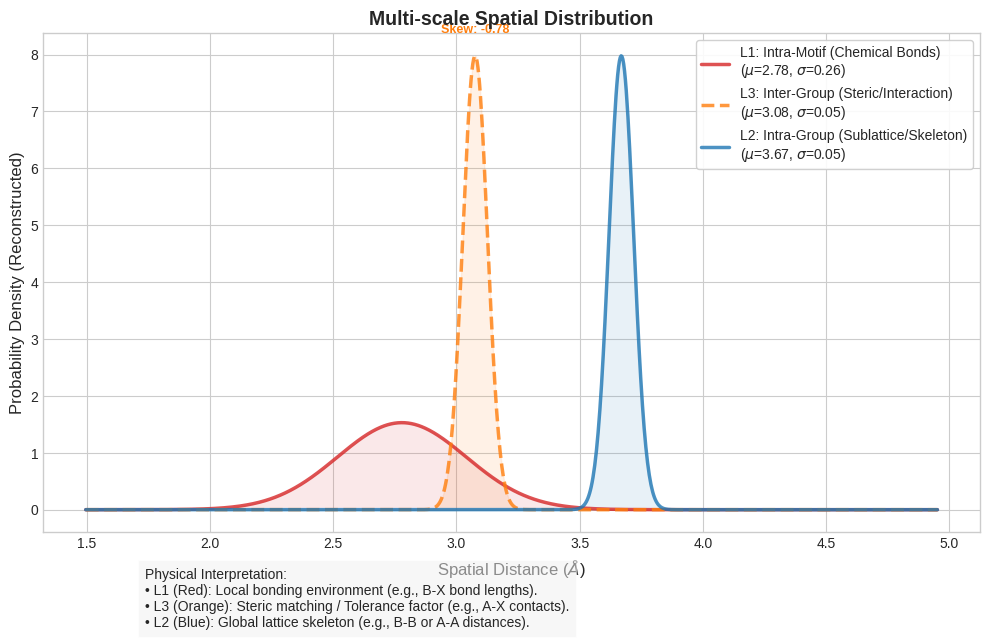

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

def visualize_three_layers_interpretability(features, title="Multi-scale Spatial Distribution"):
    """
    可视化三层空间特征：基元内部(L1)、同组晶格(L2)、异组交互(L3)。
    利用统计矩 (Mean, Std) 重构高斯分布，直观展示空间排布。
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    layers_config = [
        {'prefix': 'L1_bond',    'label': 'L1: Intra-Motif (Chemical Bonds)', 'color': '#d62728', 'style': '-'}, # Red
        {'prefix': 'L3_inter',   'label': 'L3: Inter-Group (Steric/Interaction)', 'color': '#ff7f0e', 'style': '--'}, # Orange
        {'prefix': 'L2_lattice', 'label': 'L2: Intra-Group (Sublattice/Skeleton)', 'color': '#1f77b4', 'style': '-'}  # Blue
    ]
    
    # 动态确定 x 轴范围
    means = []
    stds = []
    
    for layer in layers_config:

        mu = features.get(f"{layer['prefix']}_mean_mean", 0)
        sigma = features.get(f"{layer['prefix']}_std_mean", 0.1)
        
        if sigma < 0.05: sigma = 0.05
        
        layer['mu'] = mu
        layer['sigma'] = sigma
        
        if mu > 0:
            means.append(mu)
            stds.append(sigma)

    if not means:
        print("No valid feature data to visualize.")
        return

    x_min = max(0, min(means) - 3 * max(stds) - 0.5)
    x_max = max(means) + 3 * max(stds) + 0.5
    x = np.linspace(x_min, x_max, 1000)

    for layer in layers_config:
        if layer['mu'] == 0: continue
        
        y = norm.pdf(x, layer['mu'], layer['sigma'])
        

        ax.plot(x, y, label=f"{layer['label']}\n($\mu$={layer['mu']:.2f}, $\sigma$={layer['sigma']:.2f})", 
                color=layer['color'], linestyle=layer['style'], linewidth=2.5, alpha=0.8)
        
        ax.fill_between(x, y, color=layer['color'], alpha=0.1)

        skew_val = features.get(f"{layer['prefix']}_skew_mean", 0)
        if abs(skew_val) > 0.5:

            ax.text(layer['mu'], max(y)*1.05, f"Skew: {skew_val:.2f}", 
                    color=layer['color'], fontsize=9, ha='center', fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(r"Spatial Distance ($\AA$)", fontsize=12)
    ax.set_ylabel("Probability Density (Reconstructed)", fontsize=12)
    ax.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)

    text_str = (
        "Physical Interpretation:\n"
        "• L1 (Red): Local bonding environment (e.g., B-X bond lengths).\n"
        "• L3 (Orange): Steric matching / Tolerance factor (e.g., A-X contacts).\n"
        "• L2 (Blue): Global lattice skeleton (e.g., B-B or A-A distances)."
    )
    plt.figtext(0.15, -0.05, text_str, wrap=True, horizontalalignment='left', fontsize=10, 
                bbox=dict(facecolor='#f0f0f0', alpha=0.5, pad=5))

    plt.tight_layout()
    plt.show()


visualize_three_layers_interpretability(spatial_features)